In [2]:
%matplotlib inline
from __future__ import print_function
import numpy
import numpy.fft as fft
import matplotlib.pyplot as plt

### METODA SPECTRAL

### Transformasi Fourier Diskrit

Misalkan $y_n$ dengan $n=1, \ldots, N$ adalah urutan dari $N$ nilai yang mungkin kompleks. *Transformasi Fourier Diskrit* (DFT) dari urutan ini adalah urutan $Y_m$ dengan $m=1, \ldots, N$ di mana

$$    Y_m = \sum^N_{n=1} y_n e^{-2 \pi i(m - 1)(n - 1) / N}$$

dan dengan transformasi invers

$$    y_n = \frac{1}{N} \sum^N_{m=1} Y_m e^{2 \pi i (m - 1) (n - 1) / N}.$$

Penggunaan DFT berkisar dari diferensiasi numerik yang sangat akurat (secara spektral) hingga analisis deret waktu, pemfilteran, dan kuadratur.

Penggunaan langsung rumus-rumus ini akan membutuhkan operasi sebesar $\mathcal{O}(N^2)$ untuk melakukan transformasi. Namun, jika $N = 2^k$ untuk suatu $k \in \mathbb{Z}^+$, salah satu keajaiban komputasi modern, *Fast Fourier Transform* (FFT), dapat digunakan dengan hanya membutuhkan operasi sebesar $\mathcal{O}(N \log N)$. Ini dapat digeneralisasi (dengan membagi domain menjadi jumlah titik yang sesuai) tanpa kehilangan kecepatan secara umum. Karena keberadaan FFT yang sangat umum, kebanyakan orang akan menggunakan istilah FFT menggantikan DFT saat menjelaskan berbagai pendekatan.

### 1. Intuisi Operasi $\mathcal{O}(N^2)$ vs $\mathcal{O}(N \log N)$

Secara tradisional, DFT adalah perkalian matriks-vektor. Setiap elemen $Y_m$ membutuhkan $N$ perkalian, dan karena ada $N$ elemen, totalnya menjadi $N \times N = N^2$. FFT memecah masalah besar ini menjadi sub-masalah yang lebih kecil (strategi *divide and conquer*).

### 2. Algoritma Cooley-Tukey

Algoritma FFT yang paling umum (Cooley-Tukey) bekerja dengan memisahkan urutan $y_n$ menjadi bagian genap dan ganjil secara rekursif:

$$    Y_m = Y_m^{genap} + e^{-2\pi i (m-1)/N} Y_m^{ganjil}$$

Dengan memanfaatkan sifat periodisitas fungsi eksponensial kompleks ($e^{i\theta}$), banyak perhitungan yang dapat digunakan kembali, sehingga memangkas waktu komputasi secara drastis.

### 3. Akurasi Spektral

Dalam metode spektral, DFT digunakan untuk memindahkan data dari domain spasial ke domain frekuensi. Di domain frekuensi, operasi seperti turunan menjadi sangat sederhana (hanya perkalian dengan frekuensi $ik$). Karena FFT menggunakan seluruh informasi dari domain, kesalahan aproksimasinya berkurang secara eksponensial terhadap $N$, jauh lebih cepat daripada metode beda hingga (*finite difference*).

### Hubungan dengan Analisis Fourier


Salah satu perspektif yang dapat kita ambil untuk merumuskan metode spektral adalah merekonstruksi/mendekonstruksi fungsi periodik $y(x)$ dengan panjang gelombang $L$, berdasarkan nilai-nilainya pada set diskrit $N$ titik yang berjarak sama:


$$x_n = \frac{(n-1) L}{N}.$$

Tinjau koefisien Fourier dari fungsi $y(x)$:


$$\hat{y}_m = \frac{1}{L} \int^L_0 y(x) \exp(-i k(m) x) dx, \quad m = 0, \pm 1, \pm 2, \ldots$$


di mana bilangan gelombang (*wave number*) yang terkait dengan koefisien Fourier $m$ adalah:


$$k(m) = \frac{2 \pi m}{L}.$$


Dari koefisien-koefisien ini, kita dapat merekonstruksi fungsi $y(x)$ sebagai:


$$y(x) = \sum^\infty_{m=-\infty} \hat{y}_m \exp(i k(m) x).$$

Ingatlah bahwa kita mengetahui koefisien $\hat{y}_m \rightarrow 0$ saat $m \rightarrow \infty$. Secara khusus, jika $y(x) \in C^R$ di seluruh interval $[0, L]$, maka koefisien Fourier meluruh sebesar $\mathcal{O}(|m|^{-(R + 1)})$.

Untuk menghubungkan koefisien DFT ($Y_m$) dan koefisien Fourier ($\hat{y}_m$), kita dapat mengaproksimasi integral di atas melalui jumlah Riemann:
$$\begin{aligned}
\hat{y}*m &\approx \frac{1}{L} \sum^N*{n=1} y(x_n) \exp\left(-i k(m) x_n \right) \Delta x\
&= \frac{1}{N} \sum^N_{n=1} y(x_n) \exp\left[-i \frac{2 \pi m}{L} \frac{(n - 1) L}{N} \right] \
&= \frac{Y_m}{N}
\end{aligned}$$

Sekarang untuk merekonstruksi aproksimasi secara penuh, kita mengambil $m=1,2,\ldots,N$ dan urutan koefisien Fourier:


$$M_m = 0, 1, 2, \ldots, N / 2 - 1, - N / 2, \ldots, -1,$$


dan urutan bilangan gelombang yang bersesuaian:


$$k_m = k(M_m) = \frac{2 \pi M_m}{L}$$


untuk menghasilkan:
$$\begin{aligned}
\hat{y}*M &\approx \frac{Y_m}{N} \
y(x) &\approx y_N(x) = \sum^{N}*{m=1} \frac{Y_m}{N} \exp(i k_m x)
\end{aligned}$$

### 1. Hubungan Kontinu ke Diskrit

Penurunan di atas menunjukkan bahwa koefisien DFT ($Y_m$) sebenarnya adalah aproksimasi numerik dari integral Fourier kontinu menggunakan aturan persegi panjang (*rectangle rule*) pada titik yang berjarak sama. Karena fungsi bersifat periodik, aturan ini sangat akurat.

### 2. Peluruhan Koefisien dan Akurasi

Poin krusial dalam metode spektral adalah kecepatan peluruhan $\hat{y}_m$:

* Jika fungsi sangat mulus ($C^\infty$), koefisien meluruh lebih cepat dari pangkat polinomial apa pun (konvergensi eksponensial).
* Hal ini menjelaskan mengapa metode spektral jauh lebih unggul daripada beda hingga untuk masalah dengan solusi yang mulus.

### 3. Fenomena Aliasing

Dalam rekonstruksi $y_N(x)$, kita hanya menggunakan frekuensi hingga $N/2$. Frekuensi yang lebih tinggi dari batas ini (frekuensi Nyquist) tidak dapat dibedakan dari frekuensi rendah pada kisi diskrit. Inilah yang disebut sebagai *aliasing*.

### 4. Pengurutan Frekuensi

Urutan $M_m$ yang disebutkan ($0, \dots, N/2-1, -N/2, \dots, -1$) adalah format standar yang dihasilkan oleh algoritma FFT (seperti pada Python `numpy.fft` atau MATLAB). Frekuensi positif diletakkan di awal, diikuti oleh frekuensi negatif.

Untuk contoh di bawah ini, amati seberapa cepat koefisien FFT meluruh untuk berbagai jenis fungsi:

1. **Gelombang kotak (*Square wave*)**, $C^0$ dengan koefisien meluruh sebagai $\mathcal{O}(|M|^{-1})$. Eksak $\hat{y~}_M = -2 i / (\pi M)$ untuk $M$ ganjil.
2. **Gelombang gigi gergaji (*Saw tooth wave*)**, $C^1$ dengan koefisien meluruh sebagai $\mathcal{O}(|M|^{-2})$. Eksak $\hat{y~}_M = 2 / (\pi M)^2$ untuk $M$ ganjil.
3. **Fungsi $(1-0.6 \cos(2 \pi x / L))^{-1}$**, $C^\infty$ dengan koefisien meluruh secara *spektral* (melampaui urutan aljabar apa pun). Eksak $\hat{y~}_M = 1.25 \cdot 3^{-|M|}$.

<>:39: SyntaxWarning: invalid escape sequence '\h'
<>:39: SyntaxWarning: invalid escape sequence '\h'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16868\1329182883.py:39: SyntaxWarning: invalid escape sequence '\h'
  axes.set_ylabel("$\hat{y}$ and $Y_N$")


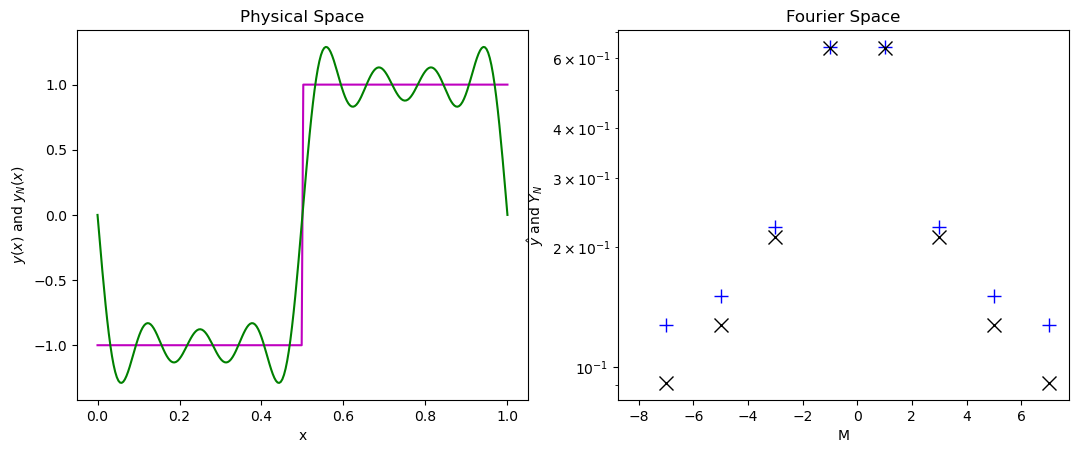

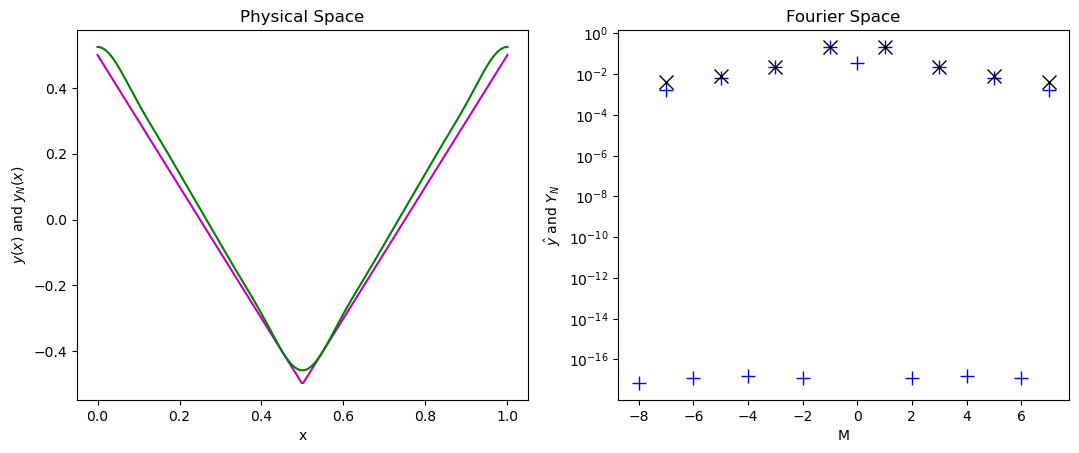

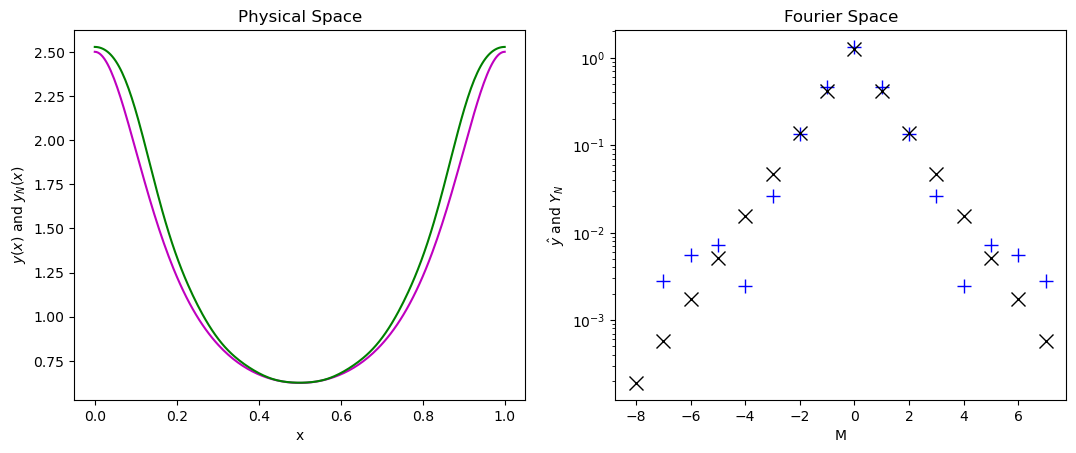

In [6]:
L = 1.0
N = 2**4
x = numpy.linspace(0.0, L, N)
delta_x = L / N
x_fine = numpy.linspace(0.0, L, 2**8)
M = fft.fftfreq(N, 1.0 / N)
M_odd = M[numpy.nonzero(numpy.ravel(numpy.mod(M, 2)))]
k = 2.0 * numpy.pi * M / L

y = [lambda x: numpy.sign(x - 0.5),
     lambda x: numpy.abs(2.0 * x - 1.0) - 0.5,
     lambda x: 1.0 / (1.0 - 0.6 * numpy.cos(2.0 * numpy.pi / L * x))]
y_hat = [lambda M:-2.0j / (numpy.pi * M),
         lambda M:2.0 / (numpy.pi * M)**2,
         lambda M:1.25 * 3.0**(-numpy.abs(M))]
    
for (i, y) in enumerate(y):
    Y = fft.fft(y(x))
    y_inv = numpy.zeros(x_fine.shape[0])
    for m in range(N):
        y_inv += ((Y[m] / N) * numpy.exp(1.0j * k[m] * (x_fine - 1.0 / (2.0 * N)))).real

    fig = plt.figure()
    fig.set_figwidth(fig.get_figwidth() * 2)
    axes = fig.add_subplot(1, 2, 1)
    axes.plot(x_fine, y(x_fine), 'm')
    axes.plot(x_fine, y_inv,'g')
    axes.set_xlabel("x")
    axes.set_ylabel("$y(x)$ and $y_N(x)$")
    axes.set_title("Physical Space")

    axes = fig.add_subplot(1, 2, 2)
    axes.semilogy(M, numpy.abs(Y) / N, '+b', markersize=10)
    if i != 2:
        axes.semilogy(M_odd, numpy.abs(y_hat[i](M_odd)) , 'xk', markersize=10)
    else:
        axes.semilogy(M, numpy.abs((y_hat[i](M))), 'xk', markersize=10)
    axes.set_xlabel("M")
    axes.set_ylabel("$\hat{y}$ and $Y_N$")
    axes.set_title("Fourier Space")

plt.show()

Secara praktis, kita dapat menyimpulkan bahwa semakin mulus sebuah fungsi, semakin sedikit koefisien Fourier yang perlu kita simpan untuk dapat menghampiri fungsi $y(x)$ tersebut dengan akurat.

Hal ini merupakan inti dari kekuatan metode spektral: untuk fungsi yang sangat mulus (seperti fungsi analitik atau $C^\infty$), tingkat kesalahan berkurang secara eksponensial terhadap jumlah titik $N$, yang jauh lebih cepat dibandingkan metode beda hingga (*finite difference*) atau elemen hingga (*finite element*) yang tingkat kesalahannya hanya berkurang secara aljabar (misalnya $\mathcal{O}(N^{-2})$ atau $\mathcal{O}(N^{-4})$).

### Sifat-Sifat DFT


Misalkan $\mathbf{y}$ adalah vektor dari nilai titik kisi $y_i$, maka DFT dan invers DFT dapat ditulis sebagai operator matriks:

$$    \mathbf{Y} = DFT(\mathbf{y}) = N^{1/2} \mathbf{F} \mathbf{y} \\
    \mathbf{y} = DFT^{-1}(\mathbf{Y}) = N^{1/2} \mathbf{F}^\ast \mathbf{Y}.$$

Di sini $\mathbf{Y}$ adalah DFT dari $\mathbf{y}$,

$$    F_{mn} = N^{-1/2} \exp(-2 \pi i (m - 1)(n - 1) / N),$$

dan $\mathbf{F}^\ast$ adalah *conjugate transpose* dari $\mathbf{F}$.

Dari sini kita juga dapat menurunkan *Identitas Parseval* untuk transformasi diskrit:
$$\begin{aligned}
\sum^N_{m=1} \frac{|Y_m|^2}{N} &= \frac{\mathbf{Y}^\ast \mathbf{Y}}{N} \
&= \mathbf{y}^\ast \mathbf{F}^\ast \mathbf{F} \mathbf{y} \
&= \mathbf{y}^\ast \mathbf{y} \
&= \sum^N_{n=1} |y_n|^2
\end{aligned}$$
menggunakan fakta bahwa $\mathbf{F}$ adalah matriks uniter (yaitu $\mathbf{F}^\ast \mathbf{F} = \mathbf{F} \mathbf{F}^\ast = \mathbf{I}$).

DFT juga mematuhi teorema konvolusi sedemikian hingga:

$$    DFT(w \ast y) = W_m Y_m$$

di mana

$$    (w \ast y)_n = \sum^N_{p=1} w_p y_{n-p}$$

adalah konvolusi dari $w$ dan $y$.

### 1. Matriks Fourier sebagai Transformasi Uniter

Matriks $\mathbf{F}$ disebut uniter karena ia mempertahankan panjang vektor. Dalam konteks fisik, ini berarti **energi** sinyal dalam domain waktu (sumbu $n$) sama dengan energi sinyal dalam domain frekuensi (sumbu $m$). Inilah inti dari **Identitas Parseval**.

### 2. Teorema Konvolusi

Sifat ini adalah salah satu yang paling krusial dalam komputasi. Konvolusi dalam domain waktu biasanya membutuhkan operasi sebesar $\mathcal{O}(N^2)$. Namun, dengan teorema ini, kita bisa:

1. Melakukan FFT pada $w$ dan $y$ ($\mathcal{O}(N \log N)$).
2. Mengalikan hasilnya secara titik demi titik (perkalian elemen-ke-elemen, $\mathcal{O}(N)$).
3. Melakukan IFFT untuk kembali ke domain waktu ($\mathcal{O}(N \log N)$).

Strategi ini jauh lebih cepat untuk data berukuran besar.

### 3. Konvolusi Sirkular

Penting untuk diingat bahwa karena DFT mengasumsikan sinyal bersifat periodik, konvolusi yang dihasilkan secara alami adalah **konvolusi sirkular**. Jika Anda ingin melakukan konvolusi linear (seperti pada pemrosesan sinyal non-periodik), Anda perlu menambahkan *zero-padding* pada vektor input agar tidak terjadi *aliasing* sirkular.

**Teorema** Kemulusan suatu fungsi dan peluruhan koefisien Fourier-nya.

Misalkan $u \in L^2(\mathbb R)$ memiliki transformasi Fourier $\hat{u}$, maka:

1. Jika $u$ memiliki turunan kontinu ke- $p-1$ dalam $L^2(\mathbb R)$ untuk suatu $p \geq 0$ dan turunan ke-$p$ dengan variasi terbatas (*bounded variation*), maka:
$$    \hat{u~}(k) = \mathcal{O}(|k|^{-p-1} ) \quad \text{saat} \quad |k| \rightarrow \infty.$$


2. Jika $u$ memiliki turunan kontinu yang tak terhingga banyaknya dalam $L^2(\mathbb R)$, maka:
$$    \hat{u~}(k) = \mathcal{O}(|k|^{-m} ) \quad \text{saat} \quad |k| \rightarrow \infty$$


untuk setiap $m \geq 0$. Hal ini juga dikenal sebagai konvergensi *spektral*. Kebalikannya juga berlaku.
3. Jika terdapat $a, c > 0$ sedemikian hingga $u$ dapat diperluas menjadi fungsi analitik dalam pita kompleks $|\Im(z)| < a$ dengan $\| u(\cdot + i y) \| \leq c$ secara seragam untuk semua $y \in (-a, a)$, di mana $\| u(\cdot + i y) \|$ adalah norma $L^2$ sepanjang garis horizontal $\Im(z) = y$, maka $u_a(k) \in L^2(\mathbb R)$, di mana $u_a(k) = e^{a |k|} \hat{u}(k)$. Kebalikannya juga berlaku.
4. Jika $u$ dapat diperluas menjadi fungsi utuh (*entire function*, yaitu analitik di seluruh bidang kompleks) dan terdapat $a > 0$ sedemikian hingga $|u(z)| = \mathcal{O}(e^{a|z|})$ saat $z \rightarrow \infty$ untuk semua nilai kompleks $z \in \mathbb C$, maka $\hat{u}$ memiliki dukungan kompak (*compact support*) yang termuat dalam $[-a, a]$. Kebalikannya juga berlaku.

### Diferensiasi

Ingatlah bahwa transformasi Fourier dari suatu turunan mengubah operasi turunan tersebut menjadi ekspresi aljabar:

$$    \widehat{(u_x)} = i \xi \hat{u~}.$$

Kita dapat memanfaatkan hal ini dalam kasus diskrit juga. Secara praktis, ini berarti untuk menghitung turunan dari suatu fungsi yang didefinisikan pada kisi (grid), kita dapat mentransformasikannya ke ruang Fourier, mengalikannya dengan bilangan gelombang yang sesuai ($i \xi$ atau $ik$), lalu melakukan transformasi balik ke ruang fisik.

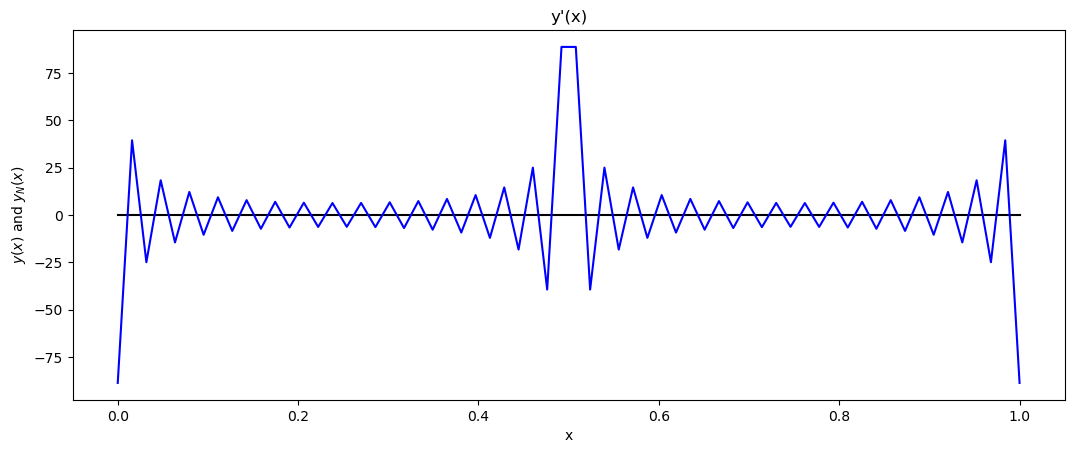

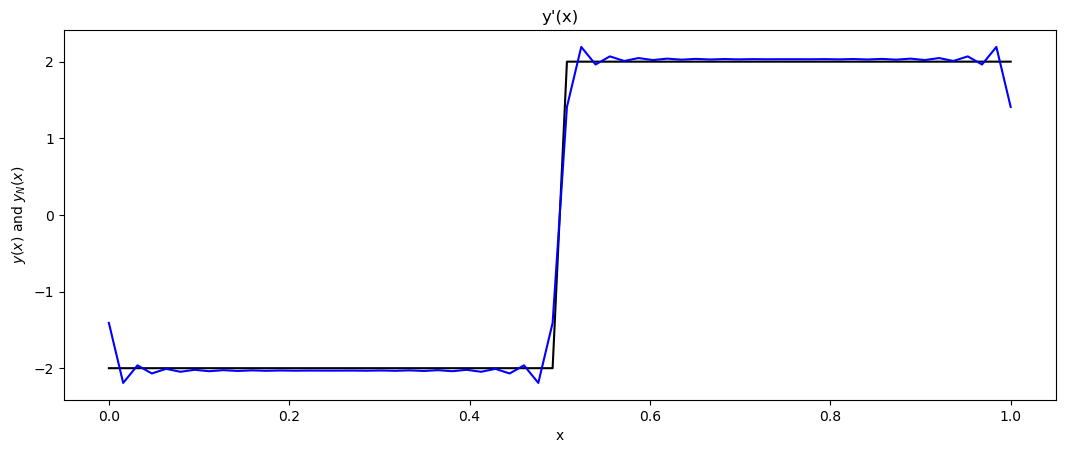

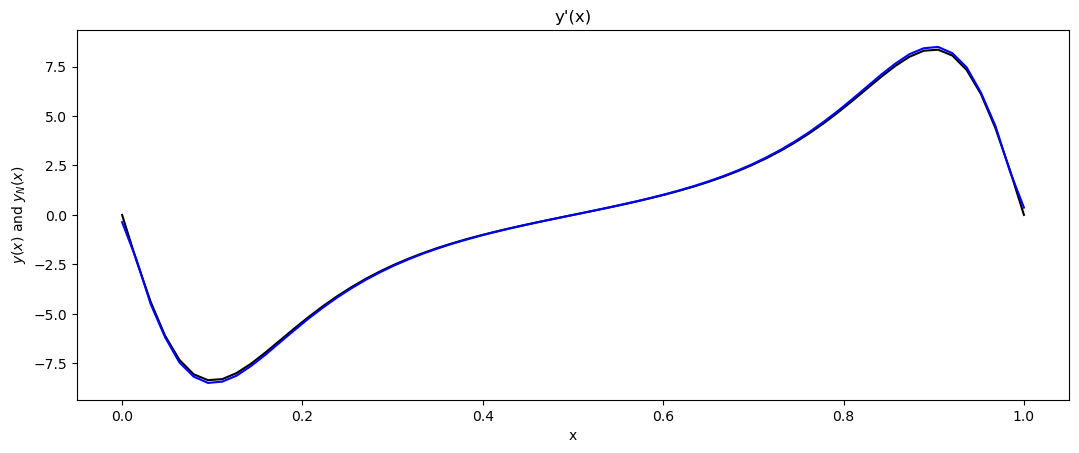

In [7]:
L = 1.0
N = 2**6
x = numpy.linspace(0.0, L, N)
M = fft.fftfreq(N, 1.0 / N)
M_odd = M[numpy.nonzero(numpy.ravel(numpy.mod(M, 2)))]
k = 2.0 * numpy.pi * M / L

y_funcs = [lambda x: numpy.sign(x - 0.5),
           lambda x: numpy.abs(2.0 * x - 1.0) - 0.5,
           lambda x: 1.0 / (1.0 - 0.6 * numpy.cos(2.0 * numpy.pi / L * x))]
y_prime_funcs = [lambda x: numpy.zeros(x.shape[0]),
                 lambda x: 2.0 * numpy.sign(x - 0.5),
                 lambda x: -1.2 * numpy.pi / L * numpy.sin(2.0 * numpy.pi / L * x) / (1.0 - 0.6 * numpy.cos(2.0 * numpy.pi / L * x))**2]

for (i, y) in enumerate(y_funcs):
    Y = fft.fft(y(x))
    y_prime = fft.ifft(1.0j * k * Y).real

    fig = plt.figure()
    fig.set_figwidth(fig.get_figwidth() * 2)
    axes = fig.add_subplot(1, 1, 1)
    axes.plot(x, y_prime_funcs[i](x), 'k')
    axes.plot(x, y_prime,'b')
    axes.set_xlabel("x")
    axes.set_ylabel("$y(x)$ and $y_N(x)$")
    axes.set_title("y'(x)")

plt.show()

Kita juga dapat menulis operasi ini sebagai operasi matriks (dengan asumsi fungsi periodik):
$$\begin{aligned}
y'(x) \approx N^{-1/2} \mathbf{F}^\ast i \mathbf{K} \mathbf{Y} = N^{-1/2} \mathbf{F}^\ast i \mathbf{K} N^{1/2} \mathbf{F} \mathbf{y} = \mathbf{D} \mathbf{y}
\end{aligned}$$
di mana $D \equiv \mathbf{F}^\ast (i \mathbf{K}) \mathbf{F}$ adalah *matriks diferensiasi pseudospektral Fourier*. Matriks ini bersifat riil, padat (*dense*), anti-simetris, dan berukuran $N \times N$. Matriks $\mathbf{K} \equiv diag(\mathbf{k})$.

Selain itu, karena $\mathbf{F}$ bersifat uniter, kita dapat menyusun beberapa turunan sekaligus hanya dengan menerapkan matriks tersebut beberapa kali untuk menemukan turunan ke-$p$.

$$    D^p = (\mathbf{F}^\ast i \mathbf{K} \mathbf{F})^p = \mathbf{F}^\ast (i \mathbf{K})^p \mathbf{F}$$

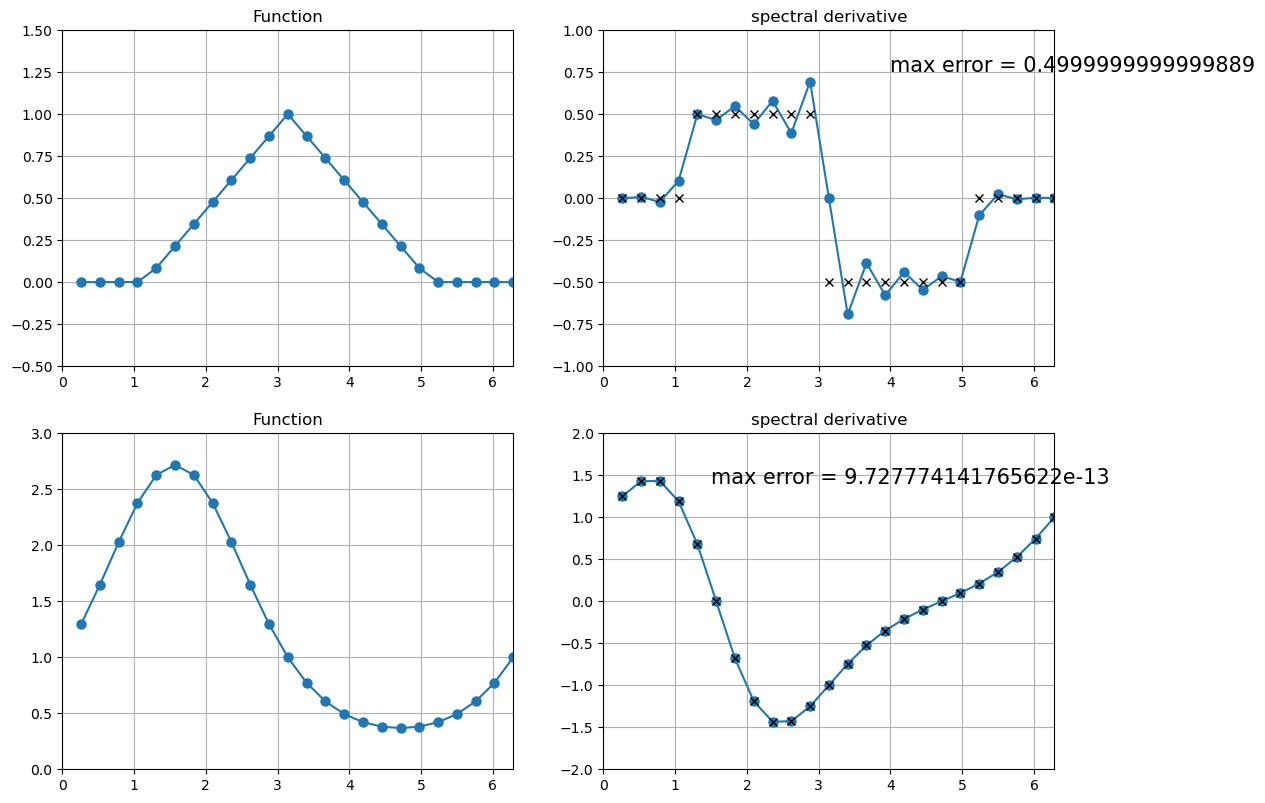

In [11]:
# Example Program 4 from Trefethen - Spectral Methods in MATLAB

import scipy.linalg as linalg

N = 24
delta_x = 2.0 * numpy.pi / N
x = numpy.linspace(delta_x, delta_x * N, N)

# Use differentiation matrix to perform derivatives
column = numpy.empty(N)
column[1:] = 0.5*(-1.0)**(numpy.arange(1, N)) * 1.0 / numpy.tan(numpy.arange(1, N) * delta_x / 2.0)
column[0] = 0.0
index_array = numpy.empty(N, dtype=int)
index_array[0] = 0
index_array[1:] = numpy.flipud(numpy.arange(1, N))
D = linalg.toeplitz(column, column[index_array])

fig, axes = plt.subplots(2, 2)
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)

# Differentiation of a hat function
v = numpy.where(1 - numpy.abs(x - numpy.pi) / 2.0 > 0.0, 1 - numpy.abs(x - numpy.pi) / 2.0, 0.0)
v_prime =  numpy.ones(x.shape) * (1 - numpy.abs(x - numpy.pi) / 2.0 > 0.0) * (x < numpy.pi) * 0.5 + \
          -numpy.ones(x.shape) * (1 - numpy.abs(x - numpy.pi) / 2.0 > 0.0) * (x > numpy.pi) * 0.5
axes[0, 0].plot(x, v, '.-', markersize=13)
axes[0, 0].set_xlim((0, 2 * numpy.pi))
axes[0, 0].set_ylim((-0.5, 1.5))
axes[0, 0].set_title("Function")
axes[0, 0].grid(True)

axes[0, 1].plot(x, numpy.dot(D, v), '.-', markersize=13)
axes[0, 1].plot(x, v_prime, 'kx')
axes[0, 1].set_xlim((0, 2*numpy.pi))
axes[0, 1].set_ylim((-1, 1))
axes[0, 1].set_title('spectral derivative')
axes[0, 1].grid(True)
error = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.inf)
axes[0, 1].text(4.0, 0.75, "max error = %s" % error, fontsize=15)

# Differentiation of exp(sin(x))
v = numpy.exp(numpy.sin(x))
v_prime = numpy.cos(x) * v
axes[1, 0].plot(x, v, '.-', markersize=13)
axes[1, 0].set_xlim((0, 2 * numpy.pi))
axes[1, 0].set_ylim((0.0, 3.0))
axes[1, 0].set_title("Function")
axes[1, 0].grid(True)

axes[1, 1].plot(x, numpy.dot(D, v), '.-', markersize=13)
axes[1, 1].plot(x, v_prime, 'kx')
axes[1, 1].set_xlim((0, 2*numpy.pi))
axes[1, 1].set_ylim((-2, 2))
axes[1, 1].set_title('spectral derivative')
axes[1, 1].grid(True)
error = numpy.linalg.norm(numpy.dot(D, v) - v_prime, ord=numpy.inf)
axes[1, 1].text(1.5, 1.4, "max error = %s" % error, fontsize=15)

plt.show()

### Metode Spektral


Kita juga dapat menerapkan pendekatan di atas jika kondisi batas periodik digunakan dan solusi yang mulus diharapkan. Mari kita periksa ini melalui sebuah contoh.

Kita ingin menyelesaikan persamaan adveksi dengan kecepatan variabel:


$$u_t + c(x) u_x = 0, \quad \Omega = [0, 2\pi]$$


dengan kondisi batas periodik dan kondisi awal:


$$u(x,0) = \exp(-100 (x - 1)^2)$$


dan kecepatan variabel:


$$c(x) = 1/5 + \sin^2(x - 1)$$

Sekarang mari kita susun metode berdasarkan *leapfrog* dan pendekatan diferensiasi di atas. Perhatikan bahwa dalam perspektif *method of lines*, kita akan memiliki:


$$\frac{U^{n+1}_j - U^{n-1}_j}{2 \Delta t} = f(U^n) = -c(x_j) (D U^n)_j$$


di mana di sini kita menggunakan matriks diferensiasi, bukan beda hingga terpusat. Kita juga dapat menggunakan metode yang (lebih efisien) berdasarkan pengetahuan tentang transformasi Fourier dari turunan. Perhatikan bahwa kita menggunakan pendekatan di sini untuk melakukan *bootstrap* pada metode tersebut.

### 1. Diferensiasi dalam Ruang Fourier

Alih-alih menggunakan matriks diferensiasi padat $D$, kita dapat menghitung turunan $u_x$ jauh lebih cepat menggunakan FFT. Ingat properti turunan:


$$\mathcal{F}(u_x) = i k \mathcal{F}(u)$$


Langkah-langkah untuk menghitung $(D U^n)_j$ adalah:

1. Hitung FFT dari solusi saat ini: $\hat{U} = \text{FFT}(U^n)$.
2. Kalikan dengan bilangan gelombang imajiner: $\hat{W}_m = i k_m \hat{U}_m$.
3. Kembalikan ke domain spasial: $w = \text{IFFT}(\hat{W})$.
4. Maka, $(D U^n)_j = w_j$.

### 2. Integrasi Waktu (Leapfrog)

Skema *leapfrog* adalah metode beda hingga terpusat untuk waktu yang bersifat eksplisit. Persamaan iterasinya menjadi:


$$U^{n+1}_j = U^{n-1}_j - 2 \Delta t \cdot c(x_j) \cdot w_j$$


Karena skema ini membutuhkan dua langkah waktu sebelumnya ($n$ dan $n-1$), langkah pertama biasanya dimulai dengan metode lain seperti Euler atau Runge-Kutta (proses *bootstrap* yang disebutkan di atas).

### 3. Keunggulan Spektral Fourier

Karena solusi $u(x,t)$ diharapkan mulus dan domainnya periodik, metode ini memiliki **akurasi spektral**. Artinya, jumlah titik kisi $N$ yang dibutuhkan untuk mencapai akurasi mesin jauh lebih sedikit dibandingkan metode beda hingga orde tinggi. Selain itu, metode ini tidak memiliki kesalahan **dispersi numerik** yang signifikan, sehingga bentuk gelombang (seperti fungsi Gaussian pada kondisi awal) tidak akan hancur atau tertinggal saat merambat.

### 4. Stabilitas (CFL)

Untuk kecepatan variabel $c(x)$, langkah waktu $\Delta t$ harus memenuhi syarat stabilitas:


$$\Delta t < \frac{\text{Const}}{N \cdot \max|c(x)|}$$


Pada metode spektral, $\Delta t$ biasanya harus lebih kecil daripada beda hingga karena operator spektral "merasakan" seluruh domain sekaligus.

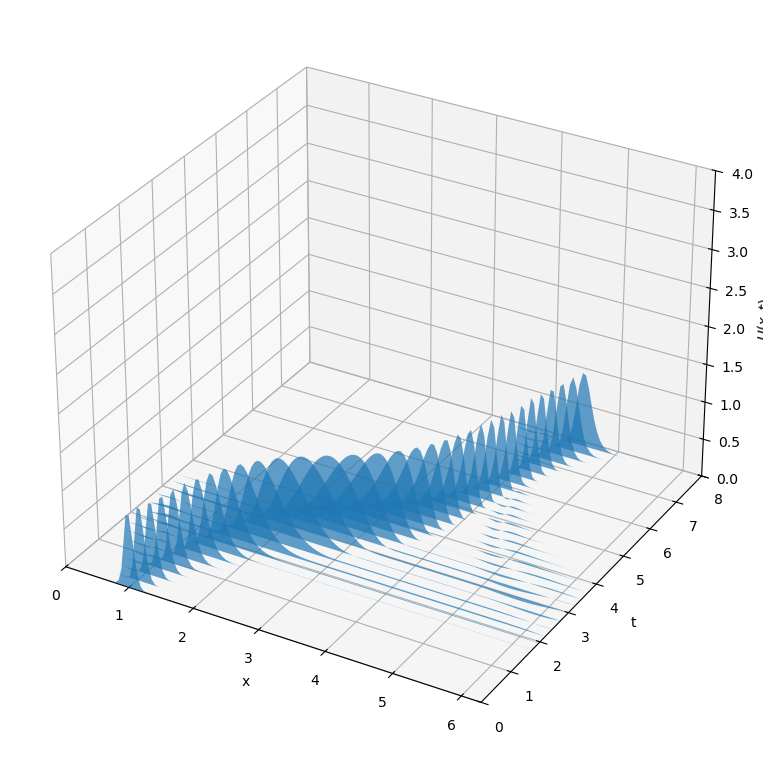

In [13]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.collections
import matplotlib.colors

# Compare a pseudo-spectral approach to a finite difference approach
# to the variable coefficient advection problem posed above

# Construct domain
N = 128
L = 2.0 * numpy.pi
delta_x = L / N
delta_t = delta_x / 4.0
x = numpy.linspace(delta_x, delta_x * N, N)
M = fft.fftfreq(N, 1.0 / N)
k = 2.0 * numpy.pi * M / L
c = 0.2 + numpy.sin(x - 1.0)**2

column = numpy.empty(N)
column[1:] = 0.5*(-1.0)**(numpy.arange(1, N)) * 1.0 / numpy.tan(numpy.arange(1, N) * delta_x / 2.0)
column[0] = 0.0
index_array = numpy.empty(N, dtype=int)
index_array[0] = 0
index_array[1:] = numpy.flipud(numpy.arange(1, N))
D = linalg.toeplitz(column, column[index_array])

U = numpy.exp(-100.0 * (x - 1.0)**2)
U_old = numpy.exp(-100.0 * (x - 0.2 * delta_t - 1.0)**2)
t_final = 8.0
num_steps = int(numpy.ceil(t_final / delta_t))
plot_interval = 20
t = 0.0
verts = []
t_output = []
for n in range(num_steps):
    # Direct discretization of derivative
#     U_hat = fft.fft(U)
#     U_prime_hat = 1.0j * k * U_hat
#     U_prime = fft.ifft(U_prime_hat).real
    # Differentiation matrix
    U_prime = numpy.dot(D, U)
    U_new = U_old - 2.0 * delta_t * c * U_prime
    U_old = U
    U = U_new

    t += delta_t
    if numpy.mod(n, plot_interval) == 0:
        t_output.append(t)
        verts.append(list(zip(x, U)))

cc = lambda arg:  matplotlib.colors.colorConverter.to_rgba(arg, alpha=0.6)
poly = matplotlib.collections.PolyCollection(verts)
poly.set_alpha(0.7)

fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)
axes = fig.add_subplot(1, 1, 1, projection='3d')
axes.add_collection3d(poly, zs=t_output, zdir='y')
axes.set_xlabel("x")
axes.set_xlim3d(0.0, 2.0 * numpy.pi)
axes.set_ylabel("t")
axes.set_ylim3d(0.0, 8.0)
axes.set_zlabel("$U(x,t)$")
axes.set_zlim(0.0, 4)

plt.show()

## Solver Poisson Berbasis FFT

Kembali ke kuliah tentang metode iteratif untuk masalah Poisson, sempat disinggung secara singkat bahwa ada cara untuk menyelesaikan masalah Poisson berdasarkan FFT. Di sini kita akan mengeksplorasi beberapa ide di balik metode yang ampuh ini.

Pertimbangkan pertama-tama masalah Poisson satu dimensi yang didefinisikan sebagai:

$$    u_{xx} = f(x), \quad \Omega = [0, L]$$

di mana $f(x)$ bersifat periodik bersama dengan kondisi batas periodik.

### Solusi dalam Ruang Fourier

Ide utamanya adalah mengubah persamaan diferensial parsial (PDE) menjadi persamaan aljabar di ruang frekuensi. Jika kita mengambil transformasi Fourier dari kedua sisi persamaan:

$$    \widehat{(u_{xx})} = \hat{f}$$

Mengingat sifat turunan dalam ruang Fourier adalah $\widehat{(u_{xx})} = (i k)^2 \hat{u} = -k^2 \hat{u}$, maka kita mendapatkan:

$$    -k^2 \hat{u}_k = \hat{f}_k$$

Dari sini, kita dapat dengan mudah menemukan koefisien Fourier dari solusi $u$:

$$    \hat{u}_k = -\frac{\hat{f}_k}{k^2}, \quad k \neq 0$$

**Catatan Penting:**

* Untuk $k=0$ (komponen DC atau rata-rata), persamaan menjadi $0 = \hat{f}_0$. Ini berarti agar solusi eksis, rata-rata dari $f(x)$ harus nol (syarat kompatibilitas).
* Solusi $u(x)$ kemudian diperoleh dengan melakukan *Inverse* FFT terhadap $\hat{u}_k$.

Satu masalah yang akan kita hadapi adalah bahwa $k_n = 0$ untuk $n=1$. Kita dapat berasumsi bahwa $F_1 = 0$ sehingga kita setidaknya bisa menangani komponen ini secara unik (secara teknis Anda masih akan menghadapi bentuk $0/0$, tetapi ada perlakuan khusus untuk kasus ini). Pertanyaannya adalah apakah kita sebaiknya benar-benar mengikuti taktik ini.

---

### Pengembangan: Masalah Singularitas dan Solusinya

Dalam menyelesaikan persamaan Poisson $u_{xx} = f(x)$ menggunakan FFT, kita bekerja dengan persamaan aljabar di ruang frekuensi:


$$\hat{u}_k = -\frac{\hat{f}_k}{k^2}$$

Masalah muncul pada komponen frekuensi nol ($k=0$), yang berhubungan dengan nilai rata-rata (*mean*) dari fungsi tersebut.

#### 1. Syarat Kompatibilitas

Secara matematis, untuk masalah Poisson dengan kondisi batas periodik, solusi hanya eksis jika rata-rata dari sumber $f(x)$ adalah nol:


$$\int_0^L f(x) dx = 0 \quad \implies \quad \hat{f}_0 = 0$$


Jika $\hat{f}_0 \neq 0$, maka persamaan tersebut tidak konsisten dan tidak memiliki solusi periodik yang stasioner.

#### 2. Menangani Bentuk $0/0$

Secara numerik, saat $k=0$, kita seringkali menetapkan $\hat{u}_0 = 0$. Secara fisik, ini berarti kita memilih solusi yang memiliki rata-rata nol di seluruh domain. Mengingat solusi persamaan Poisson hanya unik hingga penambahan konstanta ($u + C$ juga merupakan solusi), menetapkan $\hat{u}_0 = 0$ adalah cara praktis untuk memilih satu solusi spesifik dari sekumpulan solusi yang mungkin.

#### 3. Implementasi Algoritma

Langkah praktis yang biasanya diambil dalam kode (seperti menggunakan `numpy.fft`) adalah:

* Hitung $\hat{f} = FFT(f)$.
* Definisikan vektor $k$.
* Hitung $\hat{u}_k = -\hat{f}_k / k^2$ untuk semua $k \neq 0$.
* Setel $\hat{u}_0 = 0$ secara eksplisit untuk menghindari pembagian dengan nol atau NaN.
* Hitung $u = IFFT(\hat{u})$.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16868\3847248502.py:20: ComplexWarning: Casting complex values to real discards the imaginary part
  U_hat[1:] = -F[1:] / k[1:]**2


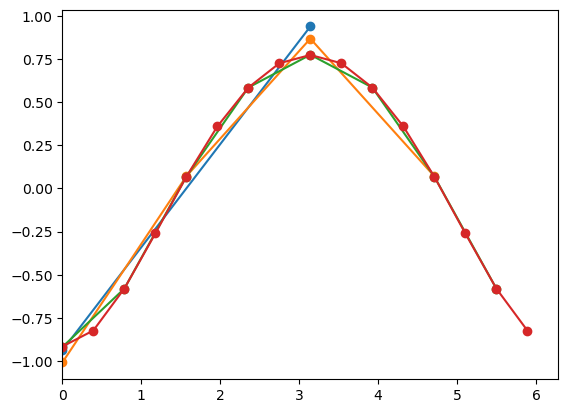

In [14]:
# Fourier spectral method for the Poisson problem
L = 2.0 * numpy.pi
f = lambda x: 1.0 / (1.0 - 0.6 * numpy.cos(2.0 * numpy.pi * x / L))

fig, axes = plt.subplots(1, 1)
for N in [2, 4, 8, 16]:
    delta_x = L / N
    delta_t = delta_x / 4.0
    x = numpy.linspace(0.0, delta_x * (N - 1), N)
    
    # Use the fft
    M = fft.fftfreq(N, 1.0 / N)
    k = 2.0 * numpy.pi * M / L

    F = fft.fft(f(x))
    if F[0] != 0:
        F = fft.fft(f(x) - F[0])
    U_hat = numpy.empty(N)
    U_hat[0] = 0.0
    U_hat[1:] = -F[1:] / k[1:]**2
    U = fft.ifft(U_hat).real

    axes.plot(x, U, 'o-')
    axes.set_xlim(0.0, L)

## Metode Spektral Chebyshev

Jadi, apa yang terjadi jika kita tidak berada pada domain periodik? Kita bisa berpikir untuk menggunakan polinom aljabar sebagai pengganti polinom trigonometri (basis Fourier kita). Namun, dari teori interpolasi, kita tahu bahwa menggunakan titik-titik dengan jarak yang sama (*equally spaced points*) adalah ide yang buruk karena adanya fenomena Runge.

Sebagai gantinya, kita akan mendistribusikan titik-titik interpolasi sedemikian rupa sehingga:

$$    x_j = \cos\left(\frac{j \pi}{N} \right), \quad j=0, 1, \ldots, N,$$

yang disebut sebagai *titik-titik Chebyshev* jenis kedua.

### Mengapa Titik Chebyshev?

Titik-titik ini lebih padat di dekat ujung-ujung interval $[-1, 1]$ dan lebih renggang di bagian tengah. Distribusi ini secara drastis mengurangi kesalahan interpolasi di dekat batas domain.

Beberapa poin penting mengenai metode ini:

* **Basis Fungsi:** Kita menggunakan polinom Chebyshev $T_n(x) = \cos(n \arccos x)$.
* **Non-Periodik:** Berbeda dengan FFT standar yang mengasumsi $u(0) = u(L)$, metode Chebyshev sangat cocok untuk masalah dengan kondisi batas Dirichlet atau Neumann yang umum (misalnya, dinding padat dalam simulasi aliran fluida).
* **Transformasi:** Meskipun basisnya adalah polinom, kita tetap bisa menggunakan FFT untuk menghitung koefisiennya dengan melakukan pemetaan melalui fungsi kosinus.

### Matriks Diferensiasi Chebyshev

Sama seperti pada kasus Fourier, kita dapat mendefinisikan matriks diferensiasi $D_N$ sedemikian rupa sehingga vektor turunan $u'$ pada titik-titik Chebyshev dapat dihitung melalui perkalian matriks $w = D_N u$. Matriks ini tidak lagi bersifat sirkulan (seperti pada Fourier), tetapi tetap sangat akurat.

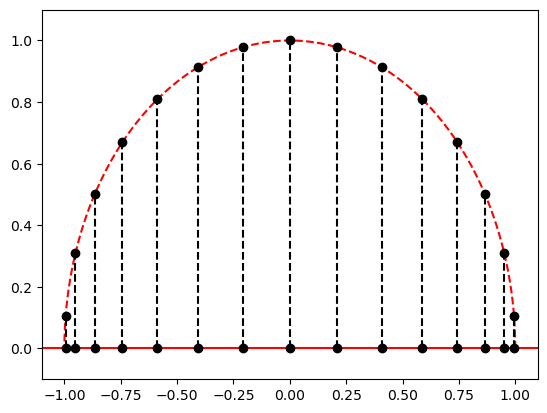

In [15]:
# Distribution of Chebyshev nodes
x = numpy.linspace(0, numpy.pi, 100)
N = 15

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

axes.plot(numpy.cos(x), numpy.sin(x), 'r--')
axes.plot(numpy.linspace(-1.1, 1.1, 100), numpy.zeros(x.shape), 'r')
for k in range(1, N + 1):
    location = [numpy.cos((2.0 * k - 1.0) * numpy.pi / (2.0 * N)),
                numpy.sin((2.0 * k - 1.0) * numpy.pi / (2.0 * N))]
    axes.plot(location[0], location[1], 'ko')
    axes.plot(location[0], 0.0, 'ko')
    axes.plot([location[0], location[0]], [0.0, location[1]], 'k--')
    
axes.set_xlim((-1.1, 1.1))
axes.set_ylim((-0.1, 1.1))
plt.show()

Dengan menggunakan basis Lagrange, kita dapat melihat secara langsung perbandingan antara penggunaan titik berjarak sama (equispaced points) dengan titik Chebyshev.

True


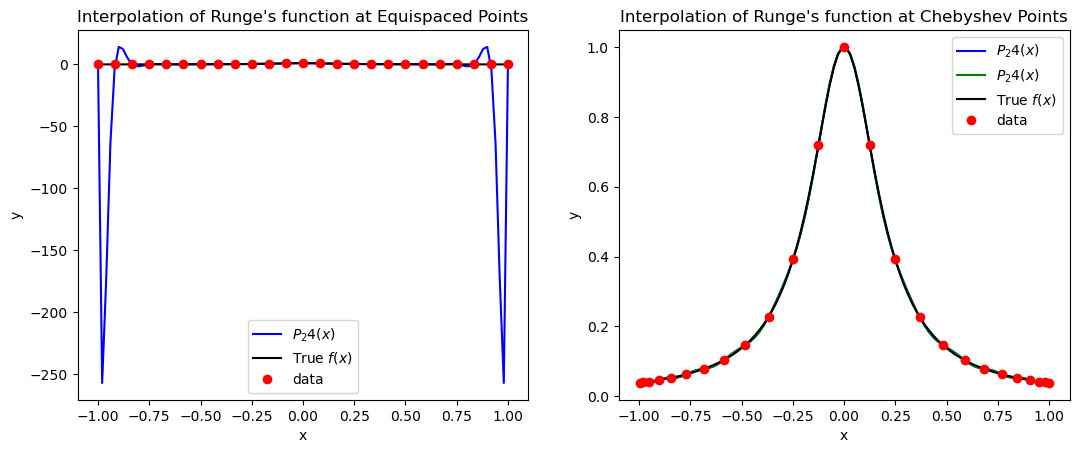

In [16]:
def f(x):
    return 1.0 / (1.0 + 25.0 * x**2)

# Parameters
x = numpy.linspace(-1, 1, 100)
num_points = 25

# ============================================================
#  Equidistant nodes
equidistant_data = numpy.empty((num_points, 2))
equidistant_data[:, 0] = numpy.linspace(-1, 1, num_points)
equidistant_data[:, 1] = f(equidistant_data[:, 0])
N = equidistant_data.shape[0] - 1

lagrange_basis = numpy.ones((N + 1, x.shape[0]))
for i in range(N + 1):
    for j in range(N + 1):
        if i != j:
            lagrange_basis[i, :] *= (x - equidistant_data[j, 0]) / (equidistant_data[i, 0] - equidistant_data[j, 0])

# Calculate full polynomial
P_lagrange = numpy.zeros(x.shape[0])
for n in range(N + 1):
    P_lagrange += lagrange_basis[n, :] * equidistant_data[n, 1]

# ============================================================
#  Chebyshev nodes
chebyshev_data = numpy.empty((num_points, 2))
chebyshev_data[:, 0] = numpy.cos((2.0 * numpy.arange(1, num_points + 1) - 1.0) * numpy.pi / (2.0 * num_points))
chebyshev_data[:, 1] = f(chebyshev_data[:, 0])

# Create interpolant based on Chebyshev nodes
lagrange_basis = numpy.ones((N + 1, x.shape[0]))
for i in range(N + 1):
    for j in range(N + 1):
        if i != j:
            lagrange_basis[i, :] *= (x - chebyshev_data[j, 0]) / (chebyshev_data[i, 0] - chebyshev_data[j, 0])

# Calculate full polynomial
P_cheby1 = numpy.zeros(x.shape[0])
for n in range(N + 1):
    P_cheby1 += lagrange_basis[n, :] * chebyshev_data[n, 1]
    
# Fit directly with Chebyshev polynomials
coeff = numpy.polynomial.chebyshev.chebfit(chebyshev_data[:, 0], chebyshev_data[:, 1], N)
P_cheby2 = numpy.polynomial.chebyshev.chebval(x, coeff)

# Check on unique polynomials
print(numpy.allclose(P_cheby1, P_cheby2))

# ============================================================
# Plot the results
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2.0)

axes = fig.add_subplot(1, 2, 1)
axes.plot(x, P_lagrange, 'b', label="$P_%s(x)$" % N)
axes.plot(x, f(x), 'k', label="True $f(x)$")
axes.plot(equidistant_data[:, 0], equidistant_data[:, 1], 'ro', label="data")
axes.set_title("Interpolation of Runge's function at Equispaced Points")
axes.set_xlabel("x")
axes.set_ylabel("y")
axes.legend(loc=8)

axes = fig.add_subplot(1, 2, 2)
axes.plot(x, P_cheby1, 'b', label="$P_%s(x)$" % N)
axes.plot(x, P_cheby2, 'g', label="$P_%s(x)$" % N)
axes.plot(x, f(x), 'k', label="True $f(x)$")
axes.plot(chebyshev_data[:, 0], chebyshev_data[:, 1], 'ro', label="data")
          
axes.set_title("Interpolation of Runge's function at Chebyshev Points")
axes.set_xlabel("x")
axes.set_ylabel("y")
axes.legend(loc=1)


plt.show()

Ada dua jenis titik (node) Chebyshev yang keduanya sama-sama efektif digunakan sebagai titik interpolasi:

1. **Titik Chebyshev Jenis ke-1 (Akar/Roots)**

$$x_k = \cos \left (\frac{(2 k - 1) \pi}{2 N} \right ) \quad k = 1, \ldots, N$$


2. **Titik Chebyshev Jenis ke-2 (Ekstremum/Extrema)**

$$x_k = \cos \left( \frac{k \pi}{N} \right) \quad k = 0, \ldots, N$$



---

### Penjelasan Sederhana (Secara Awam)

Jika Anda ingin membuat grafik atau menghitung fungsi menggunakan komputer, biasanya kita memilih titik yang jaraknya sama (seperti penggaris). Masalahnya, untuk perhitungan yang sangat akurat, cara ini justru bikin error besar di bagian ujung-ujung grafik (Fenomena Runge).

**Apa bedanya kedua jenis di atas?**

* **Idenya sama:** Bayangkan sebuah setengah lingkaran. Kita menaruh titik-titik dengan jarak yang sama di sepanjang busur lingkaran tersebut, lalu kita proyeksikan (jatuhkan tegak lurus) titik-titik itu ke garis lurus di bawahnya. Hasilnya, titik-titik di ujung akan jadi lebih rapat daripada di tengah.
* **Jenis ke-1 (Akar):** Titik-titiknya adalah posisi di mana fungsi polinim Chebyshev bernilai **nol**. Titik-titik ini "masuk sedikit" ke dalam, jadi tidak ada titik yang persis berada di ujung batas ($-1$ atau $1$).
* **Jenis ke-2 (Ekstremum):** Titik-titiknya adalah posisi di mana fungsi polinim Chebyshev mencapai nilai **maksimum atau minimum**. Keunggulannya, titik ini menyertakan ujung batas ($-1$ dan $1$) secara presisi, sehingga sangat sering dipakai dalam simulasi fisika atau teknik yang butuh kondisi batas tepat di ujung dinding.

[ 1.          0.80901699  0.30901699 -0.30901699 -0.80901699 -1.        ]
[0.54030231 0.69021008 0.95263298 0.95263298 0.69021008 0.54030231]


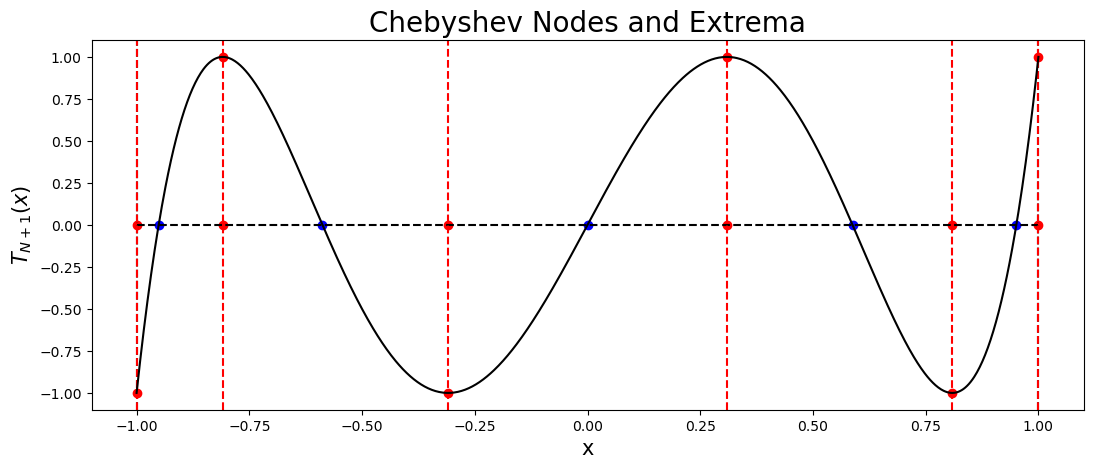

In [17]:
def cheb_poly(x, N):
    """Compute the *N*th Chebyshev polynomial and evaluate it at *x*"""
    T = numpy.empty((3, x.shape[0]))
    T[0, :] = numpy.ones(x.shape)
    T[1, :] = x
    for k in range(2, N):
        T[2, :] = 2.0 * x * T[1, :] - T[0, :]
        T[0, :] = T[1, :]
        T[1, :] = T[2, :]
    
    return T[2, :]

N = 5
x_extrema = numpy.cos(numpy.arange(N + 1) * numpy.pi / N)
x_nodes = numpy.cos((2.0 * numpy.arange(1, N + 1) - 1.0) / (2.0 * N) * numpy.pi)

fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
axes = fig.add_subplot(1, 1, 1)

# Plot points
axes.plot(x_extrema, numpy.zeros(N+1), 'ro')
axes.plot(x_nodes, numpy.zeros(N), 'bo')
    
# Plot some helpful lines
axes.plot((-1.0, -1.0), (-1.1, 1.1), 'k--')
axes.plot((1.0, 1.0), (-1.1, 1.1), 'k--')
axes.plot((-1.0, 1.0), (0.0, 0.0), 'k--')
for i in range(x_extrema.shape[0]):
    axes.plot((x_extrema[i], x_extrema[i]), (-1.1, 1.1), 'r--')
    axes.plot(x_extrema[i], cheb_poly(x_extrema, N + 1)[i], 'ro')

print(x_extrema)
print(numpy.cos(x_extrema))
    
# Plot Chebyshev polynomial
x_hat = numpy.linspace(-1, 1, 1000)
axes.plot(x_hat, cheb_poly(x_hat, N + 1), 'k')
axes.set_xlim((-1.1, 1.1))
axes.set_ylim((-1.1, 1.1))

# Labels
axes.set_title("Chebyshev Nodes and Extrema", fontsize="20")
axes.set_xlabel("x", fontsize="15")
axes.set_ylabel("$T_{N+1}(x)$", fontsize="15")

plt.show()

Satu lagi sifat menarik dari titik-titik Chebyshev adalah mereka memiliki sifat sarang (nesting) dengan periode yang berbeda. Titik jenis pertama bersarang dengan faktor 3, sementara titik jenis kedua bersarang setiap faktor 2.

Hal ini sangat berguna jika Anda sudah bersusah payah menghitung nilai fungsi pada sekumpulan titik beresolusi rendah, tetapi kemudian ingin meningkatkan jumlah titik yang digunakan (resolusi lebih tinggi). Jika Anda menggunakan faktor sarang ini, Anda dapat tetap mempertahankan lokasi titik dan data yang sudah ada sambil tetap meningkatkan resolusi keseluruhannya.

Text(0.5, 1.0, 'Chebyshev Nodes Second-Kind Nesting')

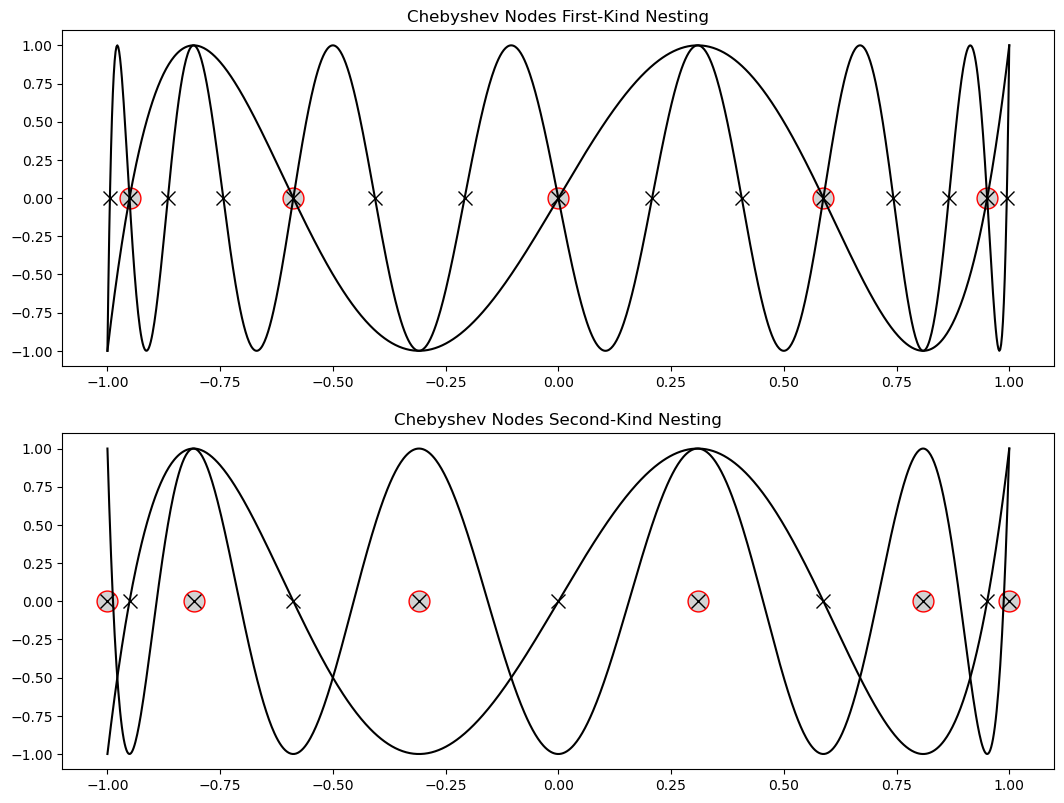

In [18]:
# First-kind Nesting (3 x)
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)
axes = fig.add_subplot(2, 1, 1)

N = 5
factor = 3
x_1 = numpy.cos((2.0 * numpy.arange(1, N + 1) - 1.0) / (2.0 * N) * numpy.pi)
x_2 = numpy.cos((2.0 * numpy.arange(1, factor * N + 1) - 1.0) / (2.0 * factor * N) * numpy.pi)

axes.plot(x_1, numpy.zeros(N), "o", color="r", markerfacecolor="lightgray", markersize="15")
axes.plot(x_2, numpy.zeros(N * factor), 'kx', markersize="10")

x_hat = numpy.linspace(-1, 1, 1000)
axes.plot(x_hat, cheb_poly(x_hat, N + 1), 'k')
axes.plot(x_hat, cheb_poly(x_hat, factor * N + 1), 'k')
axes.set_xlim((-1.1, 1.1))
axes.set_ylim((-1.1, 1.1))
axes.set_title("Chebyshev Nodes First-Kind Nesting")

# Second-kind Nesting (2 x)
axes = fig.add_subplot(2, 1, 2)
N = 5
factor = 2
x_1 = numpy.cos(numpy.arange(N + 1) * numpy.pi / N)
x_2 = numpy.cos(numpy.arange(factor * N + 1) * numpy.pi / (factor * N))

axes.plot(x_1, numpy.zeros(N + 1), "o", color="r", markerfacecolor="lightgray", markersize="15")
axes.plot(x_2, numpy.zeros(N * factor + 1), 'kx', markersize="10")

x_hat = numpy.linspace(-1, 1, 1000)
axes.plot(x_hat, cheb_poly(x_hat, N + 1), 'k')
axes.plot(x_hat, cheb_poly(x_hat, factor * N + 1), 'k')
axes.set_xlim((-1.1, 1.1))
axes.set_ylim((-1.1, 1.1))
axes.set_title("Chebyshev Nodes Second-Kind Nesting")

Salah satu cara untuk mengukur optimalitas titik-titik Chebyshev sebagai set titik interpolasi adalah dengan mempertimbangkan **fungsi Lebesgue**:

$$\lambda_N(x) = \sum_{i=0}^{N} | \ell_i(x) |$$

di mana $\ell_i(x)$ adalah fungsi basis Lagrange untuk set $x_i$ tertentu. Nilai maksimum dari fungsi Lebesgue disebut sebagai **konstanta Lebesgue** ($\Lambda_N$). Konstanta ini sangat berkaitan dengan interpolasi Lagrange karena memberikan estimasi awal untuk kesalahan interpolasi.

Sayangnya, $\Lambda_N$ tidak terbatas secara seragam (tidak memiliki batas atas tetap) terlepas dari titik apa pun yang digunakan, karena dapat dibuktikan bahwa:

$$    \Lambda_N > \mathcal{O}(\log N) \quad \text{saat} \quad N \rightarrow \infty$$

Perlu dicatat bahwa $\Lambda_N$ adalah *infinite-norm* dari operator linear yang memetakan data ke interpolan pada kisi (*grid*) dan interval yang diberikan.


Jika kita menghitung fungsi-fungsi ini untuk titik-titik berjarak sama (*equispaced*) dan setiap jenis titik Chebyshev, kita dapat melihat mengapa Chebyshev jauh lebih baik untuk interpolasi:

* **Titik Berjarak Sama (Buruk):** Untuk titik yang jaraknya sama, $\Lambda_N$ tumbuh secara **eksponensial** terhadap $N$ ($2^N$). Inilah alasan matematis di balik Fenomena Runge—kesalahan di dekat ujung interval meledak dengan sangat cepat.
* **Titik Chebyshev (Optimal):** Untuk titik Chebyshev, $\Lambda_N$ tumbuh sangat lambat, yaitu secara **logaritmik** ($\frac{2}{\pi} \log N$). Ini adalah pertumbuhan minimum yang mungkin dicapai oleh set titik mana pun. Artinya, meskipun kita menambah jumlah titik hingga sangat banyak, stabilitas interpolasinya tetap terjaga dengan sangat baik.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16868\3289461655.py:42: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[i].set_ylim((0.0, y_max + 0.1))


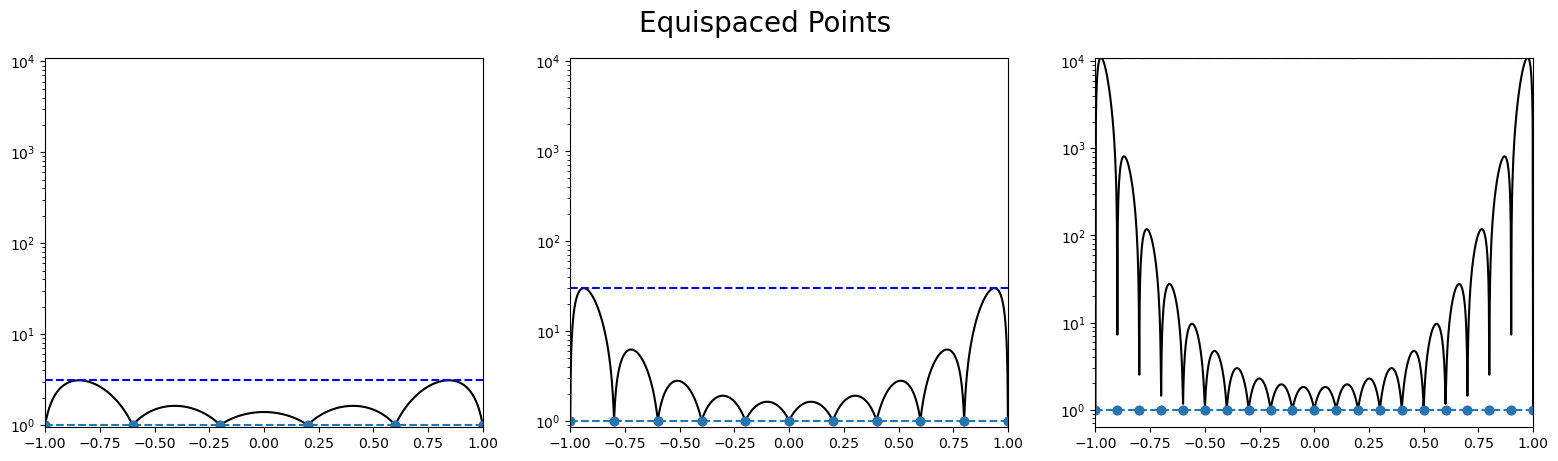

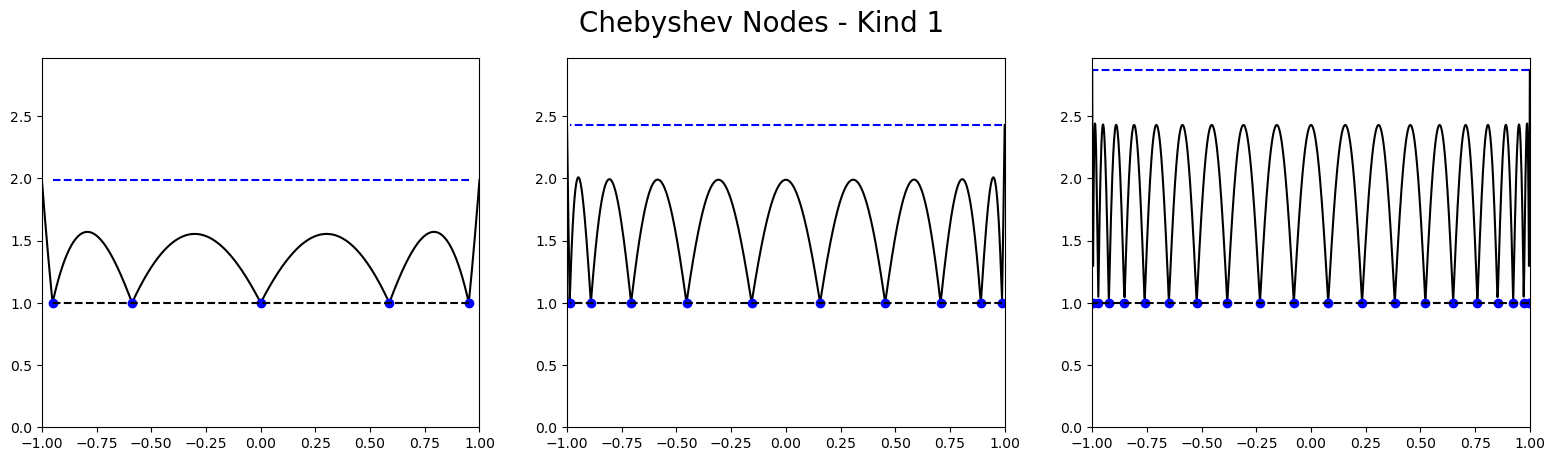

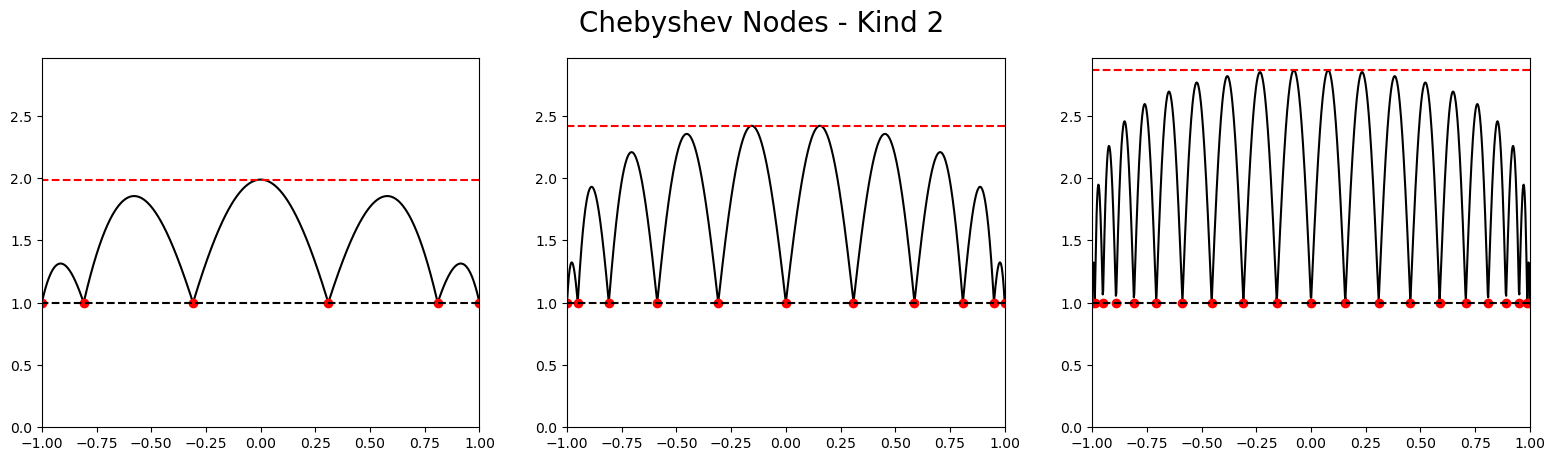

In [19]:
def lebesgue(x, data):
    """Compute the *i*th Lagrangian basis
    
    :Input:
     - *x* (numpy.ndarray) x values that basis will be evaluated at
     - *data* (numpy.ndarray) Tuples representing interpolant points
     - *i* (int) Which basis function to compute.
     
    :Output:
     - (numpy.ndarray) Contains the ith Lagrangian basis evaluated at x
    """
    
    lebesgue = numpy.zeros(x.shape[0])
    for i in range(data.shape[0]):
        lagrange_basis = numpy.ones(x.shape[0])
        for j in range(data.shape[0]):
            if i != j:
                lagrange_basis *= (x - data[j]) / (data[i] - data[j])
        lebesgue += numpy.abs(lagrange_basis)
    return lebesgue

N_range = [5, 10, 20]
x = numpy.linspace(-1, 1, 1000)

# Equispaced
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 3)
fig.suptitle("Equispaced Points", fontsize="20")
y_max = 0.0
axes = []
for (i, N) in enumerate([5, 10, 20]):
    x_hat = -1.0 + 2.0 * numpy.arange(N + 1) / N
    y = lebesgue(x, x_hat)
    axes.append(fig.add_subplot(1, 3, i + 1))
    axes[i].semilogy(x, y, 'k')
    axes[i].semilogy(x_hat, numpy.ones(N + 1), 'ro')
    axes[i].semilogy(x_hat, numpy.ones(N + 1), 'o--')
    axes[i].plot(x_hat, numpy.ones(N + 1) * numpy.max(y), 'b--')
    axes[i].set_xlim((-1, 1))
    y_max = max(y_max, numpy.max(y))
for i in range(len(N_range)):
    axes[i].set_ylim((0.0, y_max + 0.1))

# Chebysehv Nodes
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 3)
fig.suptitle("Chebyshev Nodes - Kind 1", fontsize="20")
y_max = 0.0
axes = []
for (i, N) in enumerate(N_range):
    x_hat = numpy.cos((2.0 * numpy.arange(1, N + 1) - 1.0) / (2.0 * N) * numpy.pi)
    y = lebesgue(x, x_hat)
    axes.append(fig.add_subplot(1, 3, i + 1))
    axes[i].plot(x, y, 'k')
    axes[i].plot(x_hat, numpy.ones(N), 'bo')
    axes[i].plot(x_hat, numpy.ones(N), 'k--')
    axes[i].plot(x_hat, numpy.ones(N) * numpy.max(y), 'b--')
    axes[i].set_xlim((-1, 1))
    y_max = max(y_max, numpy.max(y))
for i in range(len(N_range)):
    axes[i].set_ylim((0.0, y_max + 0.1))
    
# Chebyshev extrema - note that the maxima are the same
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 3)
fig.suptitle("Chebyshev Nodes - Kind 2", fontsize="20")
y_max = 0.0
axes = []
for (i, N) in enumerate(N_range):
    x_hat = numpy.cos(numpy.arange(N + 1) * numpy.pi / N)
    y = lebesgue(x, x_hat)
    axes.append(fig.add_subplot(1, 3, i + 1))
    axes[i].plot(x, y, 'k')
    axes[i].plot(x_hat, numpy.ones(N + 1), 'ro')
    axes[i].plot(x_hat, numpy.ones(N + 1), 'k--')
    axes[i].plot(x_hat, numpy.ones(N + 1) * numpy.max(y), 'r--')
    axes[i].set_xlim((-1, 1))
    y_max = max(y_max, numpy.max(y))
for i in range(len(N_range)):
    axes[i].set_ylim((0.0, y_max + 0.1))

Untuk menunjukkan secara nyata bahwa titik-titik (nodes) Chebyshev adalah optimal, tinjaulah polinomial monik $p(z)$ berderajat $N$ pada bidang kompleks:


$$p(z) = \prod^N_{k=1} (z - z_k)$$


di mana $z_k$ adalah akar-akar dengan multiplisitas yang mungkin tidak trivial. Dengan sedikit memanipulasi ini, kita juga dapat menuliskan ekspresi terkait:
$$\begin{aligned}
|p(z)| &= \prod^N_{k=1} |z - z_k| \
\log|p(z)| &= \sum^N_{k=1} \log|z - z_k|.
\end{aligned}$$

Polinomial disebut **monik** jika koefisien dari suku dengan derajat tertingginya ($z^N$) adalah 1. Berdasarkan Teorema Dasar Aljabar, setiap polinomial derajat $N$ dapat difaktorkan menjadi $N$ faktor linear:


$$p(z) = (z - z_1)(z - z_2) \cdots (z - z_N) = \prod^N_{k=1} (z - z_k)$$


Untuk mencari besaran $|p(z)|$, kita menggunakan sifat distributif nilai mutlak terhadap perkalian, yaitu $|a \cdot b| = |a| \cdot |b|$.


$$|p(z)| = |(z - z_1)(z - z_2) \cdots (z - z_N)|$$

$$|p(z)| = |z - z_1| \cdot |z - z_2| \cdots |z - z_N| = \prod^N_{k=1} |z - z_k|$$


Untuk mengubah perkalian menjadi penjumlahan (yang seringkali lebih mudah dianalisis dalam teori potensial), kita menerapkan fungsi logaritma natural ($\log$ atau $\ln$) pada kedua sisi:


$$\log|p(z)| = \log \left( \prod^N_{k=1} |z - z_k| \right)$$

Menggunakan sifat logaritma $\log(a \cdot b) = \log a + \log b$, maka:


$$\log|p(z)| = \log|z - z_1| + \log|z - z_2| + \dots + \log|z - z_N|$$

$$\log|p(z)| = \sum^N_{k=1} \log|z - z_k|$$

Misalkan


$$\phi_N(z) = \frac{1}{N} \sum^N_{k=1} \log |z - z_k|,$$


Karena $\phi_N(z)$ adalah *harmonik*, ia memenuhi persamaan Laplace pada bidang kompleks kecuali pada akar-akar $z_k$. Pengaturan ini dapat dipandang sebagai potensial elektrostatis dengan muatan-muatan pada akar $z_k$. Potensial dari masing-masing muatan adalah


$$\frac{\log |z - z_k|}{N}.$$

Fungsi $u(x, y)$ dikatakan harmonik jika memenuhi $\nabla^2 u = 0$.

* Diberikan fungsi kompleks $f(z) = \ln(z - z_k)$.
* Secara definisi, $\ln(w) = \ln|w| + i \arg(w)$.
* Karena $f(z)$ adalah fungsi analitik (untuk $z \neq z_k$), maka bagian riilnya, yaitu $u = \ln|z - z_k|$, secara otomatis memenuhi persamaan Laplace:

$$\left( \frac{\partial^2}{\partial x^2} + \frac{\partial^2}{\partial y^2} \right) \log |z - z_k| = 0$$



Karena operator Laplace $\nabla^2$ bersifat linear, maka:


$$\nabla^2 \phi_N(z) = \nabla^2 \left( \frac{1}{N} \sum^N_{k=1} \log |z - z_k| \right)$$

$$\nabla^2 \phi_N(z) = \frac{1}{N} \sum^N_{k=1} \nabla^2 \log |z - z_k|$$

$$\nabla^2 \phi_N(z) = \frac{1}{N} \sum^N_{k=1} 0 = 0 \quad (\text{untuk } z \neq z_k)$$


Total potensial $\phi_N(z)$ adalah hasil bagi dari total logaritma magnitudo polinomial dengan derajatnya $N$. Secara matematis, kontribusi satu titik akar $z_k$ terhadap rata-rata potensial adalah:


$$\phi_{\text{individu}} = \frac{1}{N} \cdot \log |z - z_k| = \frac{\log |z - z_k|}{N}$$

Sekarang, tinjaulah hubungan antara $|p(z)|$ dan $\phi_N(z)$. Dari ekspresi sebelumnya, kita mengetahui bahwa:


$$|p(z)| = e^{N \phi_N(z)}.$$

Jika $\phi_N(z)$ kira-kira konstan pada interval $[-1, 1]$, maka $|p(z)|$ juga demikian. Sebaliknya, jika $\phi_N(z)$ bervariasi, maka variasi $|p(z)|$ akan bersifat eksponensial, terutama dengan $N$ yang besar! Dengan memperhatikan perilaku ini, tinjaulah limit $N \rightarrow \infty$ dan titik-titik $x_j$ yang tersebar dalam $[-1, 1]$ menurut fungsi densitas $\rho(x)$ dengan:


$$\int^1_{-1} \rho(x) dx = 1.$$

Diberikan definisi rata-rata potensial:


$$\phi_N(z) = \frac{1}{N} \sum^N_{k=1} \log |z - z_k|$$

Untuk mendapatkan $|p(z)|$, kita lakukan langkah berikut:

* Kalikan kedua sisi dengan $N$:

$$N \phi_N(z) = \sum^N_{k=1} \log |z - z_k|$$


* Gunakan sifat logaritma $\sum \log(a) = \log(\prod a)$:

$$N \phi_N(z) = \log \left( \prod^N_{k=1} |z - z_k| \right)$$


* Berdasarkan definisi awal $|p(z)| = \prod |z - z_k|$, maka:

$$N \phi_N(z) = \log |p(z)|$$


* Gunakan fungsi eksponensial ($e^x$) pada kedua sisi:

$$e^{N \phi_N(z)} = |p(z)|$$


Ketika jumlah titik $N$ menjadi sangat besar, penjumlahan diskrit dalam $\phi_N(z)$ berubah menjadi integral berdasarkan distribusi densitas $\rho(x)$:


$$\phi_N(z) = \frac{1}{N} \sum^N_{k=1} \log |z - x_k| \xrightarrow{N \to \infty} \int^1_{-1} \rho(x) \log |z - x| dx$$

Dari fungsi densitas ini, kita juga mengetahui jumlah titik kisi (grid points) dalam suatu interval $[a, b]$ sebagai


$$1 = N \int^b_a \rho(x) dx.$$

Jika $\rho(x)$ adalah fungsi densitas peluang (probabilitas) dari distribusi titik-titik pada interval $[-1, 1]$, maka jumlah titik $n$ yang jatuh di dalam sub-interval $[a, b] \subseteq [-1, 1]$ adalah:


$$n = N \int^b_a \rho(x) dx$$


Agar tepat terdapat **satu** titik kisi ($n=1$) di dalam interval $[a, b]$, maka hasil perkalian antara total titik $N$ dengan probabilitas menemukan titik di $[a, b]$ haruslah bernilai satu:


$$1 = N \int^b_a \rho(x) dx$$


Persamaan ini mendefinisikan lebar interval $[a, b]$ yang diperlukan untuk mencakup tepat satu buah akar (node).

* Jika $\rho(x)$ bernilai besar (titik-titik sangat rapat), maka jarak $(b - a)$ akan sangat kecil.
* Jika $\rho(x)$ bernilai kecil (titik-titik renggang), maka jarak $(b - a)$ harus lebih lebar untuk mendapatkan satu titik.


Dari fungsi densitas ini, kita juga mengetahui jumlah titik kisi (grid points) dalam suatu interval $[a, b]$ sebagai


$$1 = N \int^b_a \rho(x) dx.$$

Rumus ini menyatakan bahwa dalam interval $[a, b]$, terdapat tepat **satu** titik kisi ($n=1$) dari total $N$ titik yang ada.

1. **Definisi Densitas:** $\rho(x)$ adalah jumlah titik per satuan panjang secara kontinu.
2. **Jumlah Titik ($n$):** Jumlah titik dalam interval $[a, b]$ adalah integral dari densitas dikalikan total titik $N$:

$$n = N \int^b_a \rho(x) dx$$


3. **Kondisi Satu Titik:** Jika kita mengatur interval $[a, b]$ sedemikian rupa sehingga hanya mencakup satu buah titik kisi ($n=1$), maka:

$$1 = N \int^b_a \rho(x) dx$$



atau secara ekuivalen:

$$\int^b_a \rho(x) dx = \frac{1}{N}$$


Ini menunjukkan bahwa pada area dengan densitas $\rho(x)$ yang tinggi, jarak antar titik $(b-a)$ akan sangat kecil (titik lebih rapat).

Menggunakan kerangka kerja ini, kita dapat menuliskan potensial sebagai


$$\phi(z) = \int^1_{-1} \rho(x) \log |z - x| dx.$$


Dalam limit $N \rightarrow \infty$, kita dapat menunjukkan bahwa untuk titik-titik dengan jarak yang sama (equispaced) berlaku


$$\phi(z) = -1 +\frac{1}{2} \text{Re}((z + 1) \log(z + 1) - (z-1)\log(z-1)).$$


Perhatikan bahwa $\phi(0) = -1$ dan $\phi(\pm 1) = -1 + \log 2$, yang menyiratkan bahwa jika sebuah polinomial $p$ memiliki akar-akar berjarak sama pada $[-1, 1]$, maka polinomial tersebut akan memiliki nilai yang $2^N$ lebih besar di dekat titik $\pm 1$ dibandingkan di dekat $0$.

Untuk titik-titik yang tersebar merata (equispaced) pada interval $[-1, 1]$, fungsi densitasnya adalah konstan: $\rho(x) = \frac{1}{2}$ (karena total panjang interval adalah 2 dan $\int_{-1}^1 \rho(x) dx = 1$).
Maka integral potensialnya menjadi:


$$\phi(z) = \int_{-1}^{1} \frac{1}{2} \log |z - x| dx$$

Gunakan substitusi $u = z - x$, sehingga $du = -dx$. Batas integral berubah dari $[z+1, z-1]$:


$$\phi(z) = -\frac{1}{2} \int_{z+1}^{z-1} \log |u| du = \frac{1}{2} \int_{z-1}^{z+1} \log |u| du$$


Mengingat integral $\int \log u \, du = u \log u - u$:


$$\phi(z) = \frac{1}{2} \Big[ u \log u - u \Big]_{z-1}^{z+1}$$

$$\phi(z) = \frac{1}{2} \Big( (z+1)\log(z+1) - (z+1) - [(z-1)\log(z-1) - (z-1)] \Big)$$


Sederhanakan bagian konstanta: $-(z+1) + (z-1) = -2$.


$$\phi(z) = -1 + \frac{1}{2} \Big( (z+1)\log(z+1) - (z-1)\log(z-1) \Big)$$


(Untuk $z$ kompleks, kita mengambil bagian riil $\text{Re}$ agar sesuai dengan $\log |z-x|$).

Gunakan hubungan $|p(z)| = e^{N \phi(z)}$:

* **Di tengah ($z=0$):** $|p(0)| = e^{N \phi(0)} = e^{-N}$.
* **Di ujung ($z=1$):** $|p(1)| = e^{N (-1 + \log 2)} = e^{-N} \cdot e^{N \log 2} = e^{-N} \cdot 2^N$.

**Kesimpulan:**
Rasio nilai di ujung dibanding di tengah adalah:


$$\frac{|p(1)|}{|p(0)|} = \frac{e^{-N} \cdot 2^N}{e^{-N}} = 2^N$$


Inilah alasan mengapa titik berjarak sama sangat buruk untuk interpolasi (Fenomena Runge), karena variasi nilainya meledak secara eksponensial sebesar $2^N$ di dekat ujung interval.

Sebaliknya, jika kita mempertimbangkan distribusi untuk titik-titik Chebyshev


$$\rho(x) = \frac{1}{\pi \sqrt{1 - x^2}}, \quad x \in [-1, 1]$$


kita dapat menunjukkan bahwa potensial yang dihasilkan adalah


$$\phi(z) = \log \frac{\left| z - \sqrt{z^2 - 1} \right|}{2}.$$

Untuk menurunkan potensial $\phi(z)$, kita mengevaluasi integral berikut:


$$\phi(z) = \int_{-1}^{1} \frac{1}{\pi \sqrt{1 - x^2}} \log |z - x| \, dx$$

Gunakan substitusi trigonometri $x = \cos \theta$, maka $dx = -\sin \theta \, d\theta$.
Karena $\sqrt{1 - x^2} = \sin \theta$, maka $\frac{dx}{\sqrt{1 - x^2}} = -d\theta$.
Batas integral berubah dari $x \in [-1, 1]$ menjadi $\theta \in [\pi, 0]$.

$$\phi(z) = \frac{1}{\pi} \int_{0}^{\pi} \log |z - \cos \theta| \, d\theta$$


Gunakan bentuk eksponensial $\cos \theta = \frac{e^{i\theta} + e^{-i\theta}}{2}$. Integral ini dapat diselesaikan dengan teknik integrasi kompleks atau menggunakan identitas standar integral logaritma:


$$\frac{1}{\pi} \int_{0}^{\pi} \log |z - \cos \theta| \, d\theta = \log \left| \frac{z + \sqrt{z^2 - 1}}{2} \right| \quad \text{atau} \quad \log \left| \frac{z - \sqrt{z^2 - 1}}{2} \right|$$


Karena $|z + \sqrt{z^2 - 1}| \cdot |z - \sqrt{z^2 - 1}| = |z^2 - (z^2 - 1)| = 1$, maka:


$$\log \left| \frac{z + \sqrt{z^2 - 1}}{2} \right| = \log \left| \frac{1}{2(z - \sqrt{z^2 - 1})} \right|$$


Dalam konteks titik Chebyshev, kita memilih solusi yang memberikan potensial konstan pada interval $[-1, 1]$. Jika $z = x \in [-1, 1]$, maka $\sqrt{z^2 - 1}$ menjadi imajiner, dan magnitudo dari pembilang $|z - \sqrt{z^2 - 1}|$ selalu bernilai **1**.

Sehingga, pada interval $[-1, 1]$:


$$\phi(x) = \log \frac{1}{2} = -\log 2$$

Ini membuktikan bahwa titik Chebyshev menghasilkan potensial yang **konstan** ($\phi = -\log 2$) di sepanjang interval, sehingga $|p(x)| = e^{N \phi} = 2^{-N}$ tidak mengalami lonjakan eksponensial seperti pada titik berjarak sama.

Rumus ini memiliki interpretasi sederhana: kurva level $\phi(z)$ berbentuk elips dengan fokus $\pm 1$. Nilai $\phi(z)$ pada elips tersebut adalah logaritma dari setengah jumlah sumbu semimayor dan semiminornya. Interval $[-1, 1]$ adalah elips degenerasi dengan nilai konstan $-\log 2$. Ini bersifat optimal dengan pertumbuhan polinomial:


$$|p(x)| = e^{N \phi(x)} \approx 2^{-N}, \quad x \in [-1, 1].$$

Gunakan transformasi $z = \frac{1}{2}(w + w^{-1})$. Lingkaran $|w|=R$ di bidang $w$ memetakan ke elips di bidang $z$ dengan:

* Sumbu semimayor + semiminor: $a + b = R$.
* Potensial: $\phi(z) = \log(R/2) = \log(\frac{a+b}{2})$.

Interval $[-1, 1]$ tercapai saat elips memipih ($R=1$):


$$\phi(x) = \log(1/2) = -\log 2.$$

Substitusikan nilai $\phi(x)$ ke hubungan $|p(x)| = e^{N\phi(x)}$:


$$|p(x)| = e^{N(-\log 2)} = (e^{\log 2})^{-N} = 2^{-N}.$$

Karena $\phi(x)$ bernilai konstan di seluruh interval, maka $|p(x)|$ tidak memiliki lonjakan nilai (seragam), yang merupakan syarat polinomial optimal (minimax).

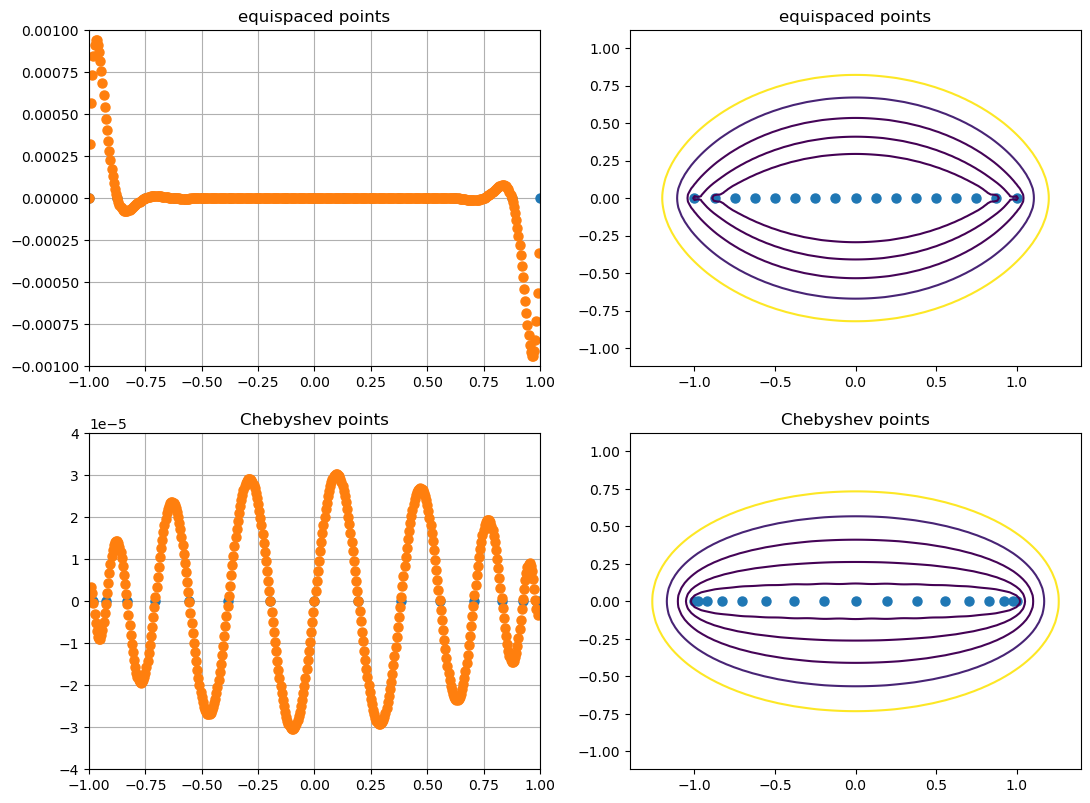

In [3]:
# Adapted from program 10 in Trefethen - "Spectral Methods for MATLAB"
N = 16

fig, axes = plt.subplots(2, 2)
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)

for (i, point_distribution) in enumerate(("equispaced points", "Chebyshev points")):
    if i == 0:
        x = -1.0 + 2.0 * numpy.arange(N + 1) / N
    else:
        x = numpy.cos(numpy.pi * numpy.arange(N+1) / N)
    
    # Construct polynomial with roots at x
    p = numpy.poly(x)
    
    # Plot p(x) over [-1, 1]
    x_fine = numpy.arange(-1, 1, .005)
    axes[i, 0].plot(x, 0*x, '.', markersize=13)
    axes[i, 0].plot(x_fine, numpy.polyval(p, x_fine), '.', markersize=13)
    axes[i, 0].grid(True)
    axes[i, 0].set_title(point_distribution)
    axes[i, 0].set_xlim((-1, 1))
    if i == 0:
        axes[i, 0].set_ylim((-1e-3, 1e-3))
    else:
        axes[i, 0].set_ylim((-4e-5, 4e-5))
    
    # Plot equipotential curves
    axes[i, 1].plot(x.real, x.imag, '.', markersize=13)
    axes[i, 1].set_xlim((-1.4, 1.4))
    axes[i, 1].set_ylim((-1.12, 1.12))
    X, Y = numpy.meshgrid(numpy.arange(-1.4, 1.4, 0.02), 
                          numpy.arange(-1.12, 1.12, 0.02))
    levels = 10**(numpy.arange(-4.0, 1.0))
    axes[i, 1].contour(X, Y, numpy.abs(numpy.polyval(p, X + 1j * Y)), levels)
    axes[i, 1].set_title(point_distribution)

### Diferensiasi Chebyshev
Salah satu cara kita menurunkan beda hingga (finite differences) adalah dengan menginterpolasi polinomial melalui titik-titik stensil dan mengambil turunan dari interpolan yang dihasilkan. Kita dapat melakukan hal yang sama untuk menemukan matriks diferensiasi Chebyshev. Karena interpolan apa pun bersifat unik berdasarkan titik-titik yang dilaluinya, kita hanya perlu menentukan turunannya berdasarkan titik-titik (nodes) Chebyshev itu sendiri.

Misalkan


$$p_N(x_j) = v_j, \quad 0 \leq j \leq N$$


adalah polinomial berderajat $N$, maka turunan yang dihasilkan adalah


$$p'_N(x_j) = w_j.$$

Karena operasi ini linear, kita dapat menyusunnya sebagai perkalian dengan sebuah matriks:


$$\mathbf{w} = \mathbf{D}_N \mathbf{v}$$

Sebagai contoh, tinjaulah kasus $N=1$, maka titik-titik interpolasinya adalah $x_0 = 1$ dan $x_1 = -1$ yang menghasilkan


$$p_1(x) = \frac{1}{2} (1  + x)v_0 + \frac{1}{2}(1 - x)v_1$$


di mana


$$p'_1(x) = \frac{1}{2}(v_0 - v_1).$$


Matriks yang dihasilkan adalah


$$D_1 = \begin{bmatrix} 1/2 & -1/2 \\ 1/2 & -1/2 \end{bmatrix}.$$

Untuk kasus $N=2$, kita memiliki titik-titik $x_0 = 1$, $x_1 = 0$, dan $x_2 = -1$ dengan interpolan kuadratik


$$p_2(x) = \frac{1}{2} x ( 1 + x) v_0 + (1+x)(1-x)v_1 + \frac{1}{2} x (x-1) v_2$$


yang menghasilkan turunan


$$p'_2(x) = (x+ 1/2) v_0 - 2 x v_1 + (x-1/2)v_2$$


dan matriks diferensiasi


$$D_2 = \begin{bmatrix} 3/2  & -2 & 1/2 \\ 1/2  &  0 & -1/2 \\ -1/2 &  2 & -3/2 \end{bmatrix}.$$

Perhatikan bahwa pada kedua kasus ini, rumus-rumusnya mengambil bentuk yang familiar, namun matriks diferensiasinya memiliki sifat tambahan *one-sided* (satu sisi). Untuk aproksimasi tingkat tinggi, metode ini berbeda dari metode beda hingga biasa karena jarak titik-titik yang tidak seragam. Secara umum, matriks diferensiasi Chebyshev mengambil bentuk:
$$\begin{aligned}
(D_N)*{00} = \frac{2 N^2 + 1}{6}, & & (D_N)*{NN} = -\frac{2N^2 + 1}{6}, \
(D_N)*{jj} = \frac{-x_j}{2(1 - x_j^2)}, & & j=1,\ldots,N-1 \
(D_N)*{ij} = \frac{c_i(-1)^{i+j}}{c_j (x_i - x_j)}, & & i\neq j, ~~ i,j = 0, \ldots, N
\end{aligned}$$
di mana


$$c_i = \left \{ \begin{aligned} 2, & & i=0 \text{ atau } N \\ 1, & & \text{lainnya}. \end{aligned} \right .$$

### 1. Kasus $N=1$ (Linear)

* **Basis Lagrange:** Untuk titik $x_0=1, x_1=-1$, basisnya adalah $L_0(x) = \frac{x-x_1}{x_0-x_1} = \frac{x+1}{2}$ dan $L_1(x) = \frac{x-x_0}{x_1-x_0} = \frac{x-1}{-2} = \frac{1-x}{2}$.
* **Turunan:** $L'_0(x) = 1/2$ dan $L'_1(x) = -1/2$.
* **Evaluasi:** Karena turunan konstan, maka di $x_0$ maupun $x_1$, nilainya tetap $1/2$ dan $-1/2$. Ini mengisi baris 1 dan baris 2 pada $D_1$.

### 2. Kasus $N=2$ (Kuadratik)

* **Turunan $p_2(x)$:** 
$$\frac{d}{dx} \left[ \frac{1}{2}(x^2+x)v_0 + (1-x^2)v_1 + \frac{1}{2}(x^2-x)v_2 \right] = (x + 1/2)v_0 - 2xv_1 + (x - 1/2)v_2$$


* **Elemen Matriks:** Evaluasi $p'_2(x)$ pada titik-titik kisi:
* $x_0 = 1: (1+1/2)v_0 - 2(1)v_1 + (1-1/2)v_2 = \mathbf{1.5v_0 - 2v_1 + 0.5v_2}$ (Baris 1)
* $x_1 = 0: (0+1/2)v_0 - 2(0)v_1 + (0-1/2)v_2 = \mathbf{0.5v_0 + 0v_1 - 0.5v_2}$ (Baris 2)
* $x_2 = -1: (-1+1/2)v_0 - 2(-1)v_1 + (-1-1/2)v_2 = \mathbf{-0.5v_0 + 2v_1 - 1.5v_2}$ (Baris 3)



### 3. Struktur Umum $D_{ij}$

Penurunan entri $i \neq j$ secara umum didapat dari menurunkan identitas polinomial Lagrange:


$$L_j(x) = \frac{a(x)}{(x-x_j)a'(x_j)}, \quad a(x) = \prod (x-x_i)$$


Turunan di $x = x_i$ menghasilkan bentuk $\frac{a'(x_i)}{(x_i-x_j)a'(x_j)}$, yang untuk titik-titik ekstrim Chebyshev menyederhanakan menjadi rumus $(-1)^{i+j}$ dengan faktor koreksi $c_i/c_j$ pada ujung-ujung interval.

In [10]:
import numpy as np

def cheb(N):
    if N == 0:
        return 0, 1

    x = np.cos(np.pi * np.arange(N+1) / N)

    c = np.ones(N+1)
    c[0] = 2
    c[-1] = 2
    c = c * (-1)**np.arange(N+1)

    X = np.tile(x, (N+1,1))
    dX = X - X.T

    D = (np.outer(c,1/c))/(dX + np.eye(N+1))
    D = D - np.diag(np.sum(D, axis=1))

    return D, x

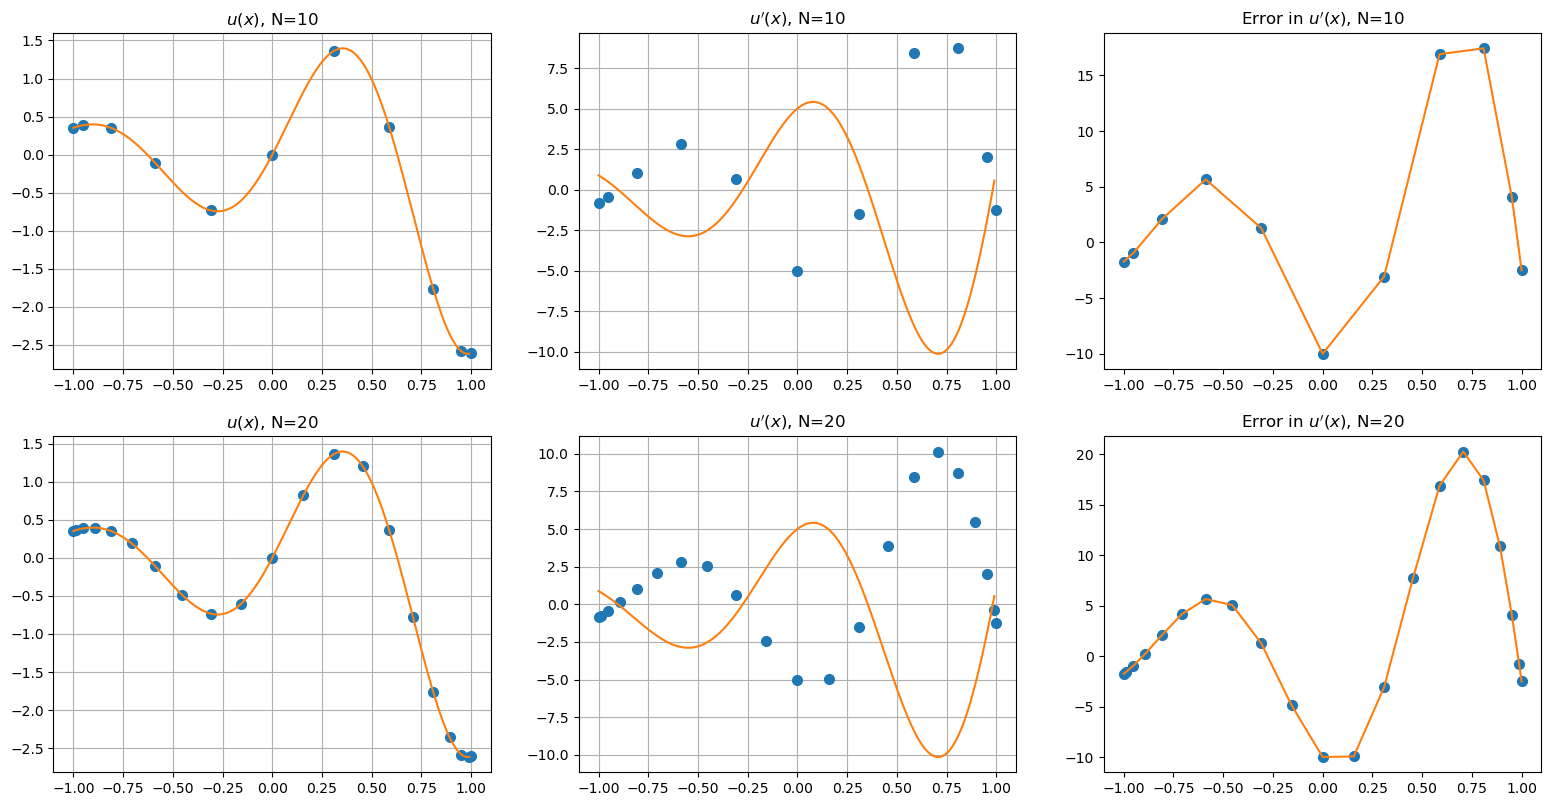

In [11]:
# Test out some differentiation on a smooth function
u = lambda x: numpy.exp(x) * numpy.sin(5.0 * x)
u_prime = lambda x: numpy.exp(x) * (numpy.sin(5.0 * x) + 5.0 * numpy.cos(5.0 * x))

x_fine = numpy.arange(-1, 1, 0.01)
fig, axes = plt.subplots(2, 3)
fig.set_figwidth(fig.get_figwidth() * 3)
fig.set_figheight(fig.get_figheight() * 2)
for (i, N) in enumerate((10, 20)):
    D, x = cheb(N)
    axes[i, 0].plot(x, u(x), '.', markersize=14)
    axes[i, 0].grid(True)
    axes[i, 0].plot(x_fine, u(x_fine))
    axes[i, 0].set_title('$u(x)$, N=%s' % N)

    axes[i, 1].plot(x, numpy.dot(D, u(x)), '.', markersize=14)
    axes[i, 1].grid(True)
    axes[i, 1].plot(x_fine, u_prime(x_fine))
    axes[i, 1].set_title("$u'(x)$, N=%s" % N)
    
    error = numpy.dot(D, u(x)) - u_prime(x)
    axes[i, 2].plot(x, error, '.', markersize=14)
    axes[i, 2].plot(x, error)
    axes[i, 2].set_title("Error in $u'(x)$, N=%s" % N)

plt.show()

Sebagai aplikasi lain dari matriks diferensiasi Chebyshev, kita juga dapat menggunakannya untuk menghitung solusi dari masalah Poisson dengan kondisi batas non-periodik. Tinjau masalah berikut:


$$u_{xx} = e^{4x},\quad \Omega = [-1, 1], \quad u(\pm 1) = 0$$


yang memiliki solusi:


$$u(x) = \frac{e^{4x} - x \sinh(4) - \cosh(4)}{16}.$$


Melanjutkan dari sebelumnya, kita kemudian memiliki:


$$D^2_N U = F$$


yang kemudian dapat dibalik (*inverted*) untuk menemukan solusinya.

Untuk menyelesaikan persamaan diferensial secara numerik, kita mengganti operator kontinu dengan operator matriks:

* $u_{xx} \rightarrow D_N^2$ (Matriks diferensiasi kedua, yaitu kuadrat dari $D_N$).
* $u(x) \rightarrow U$ (Vektor nilai solusi pada titik-titik kisi $x_j$).
* $e^{4x} \rightarrow F$ (Vektor sumber yang dievaluasi pada titik-titik kisi $x_j$).

Maka persamaan menjadi sistem linear:


$$D_N^2 U = F$$


Matriks $D_N^2$ berukuran $(N+1) \times (N+1)$ bersifat *singular* (tidak dapat dibalik) sebelum kondisi batas diterapkan. Karena $u(-1) = 0$ dan $u(1) = 0$:

* Kita menghapus baris pertama dan terakhir serta kolom pertama dan terakhir dari matriks $D_N^2$.
* Ini menyisakan matriks interior $\tilde{D}^2$ berukuran $(N-1) \times (N-1)$.
* Sistem yang dapat diselesaikan adalah:

$$\tilde{D}^2 U_{int} = F_{int}$$


Untuk membuktikan solusi analitik yang diberikan, kita integralkan $u_{xx} = e^{4x}$ dua kali:

1. $u_x = \frac{1}{4} e^{4x} + C_1$
2. $u = \frac{1}{16} e^{4x} + C_1 x + C_2$

Dengan memasukkan $u(1)=0$ dan $u(-1)=0$:

* $0 = \frac{1}{16} e^4 + C_1 + C_2$
* $0 = \frac{1}{16} e^{-4} - C_1 + C_2$

Menyelesaikan sistem linear untuk $C_1$ dan $C_2$ menghasilkan:

* $C_2 = -\frac{1}{16} \frac{e^4 + e^{-4}}{2} = -\frac{\cosh(4)}{16}$
* $C_1 = -\frac{1}{16} \frac{e^4 - e^{-4}}{2} = -\frac{\sinh(4)}{16}$

Substitusi kembali ke persamaan $u$ menghasilkan solusi yang sesuai dengan teks.


Solusi numerik diperoleh dengan:


$$U_{int} = (\tilde{D}^2)^{-1} F_{int}$$


Karena akurasi spektral Chebyshev, solusi ini akan konvergen ke solusi analitik jauh lebih cepat daripada metode beda hingga standar saat $N$ bertambah.

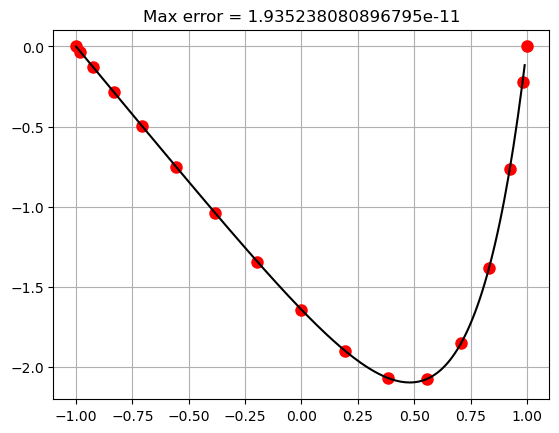

In [13]:
# Adapted from Trefethen program 13
f = lambda x: numpy.exp(4.0 * x)
u_true = lambda x: (numpy.exp(4.0 * x) - x * numpy.sinh(4.0) - numpy.cosh(4.0)) / 16.0

N = 16
x_fine = numpy.arange(-1, 1, 0.01)

# Compute square and remove boundaries
D, x = cheb(N)
D2 = numpy.dot(D, D)[1:-1, 1:-1]

# Solve problem
U = numpy.zeros(N + 1)
U[1:-1] = numpy.linalg.solve(D2, f(x[1:-1]))
error = numpy.linalg.norm(U - u_true(x), ord=numpy.inf)

# Plot results
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x, U, 'r.', markersize=16)
axes.plot(x_fine, u_true(x_fine), 'k')
axes.grid(True)
axes.set_title("Max error = %s" % error)
plt.show()

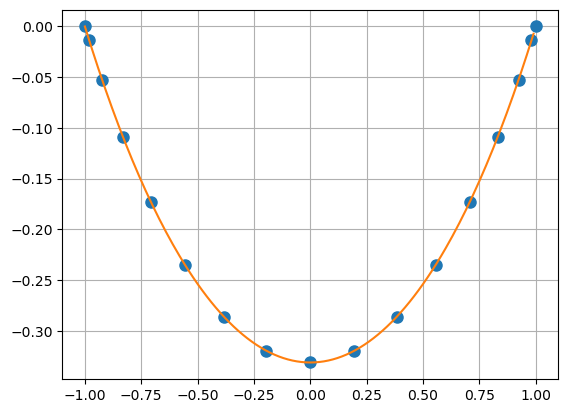

In [15]:
# Adapted from Trefethen program 14 - Non-linear Elliptic
f = lambda u: numpy.exp(u)

N = 16
x_fine = numpy.arange(-1, 1, 0.01)

# Compute square and remove boundaries
D, x = cheb(N)
D2 = numpy.dot(D, D)[1:-1, 1:-1]

# Solve problem using fixed point iteration
U = numpy.zeros(N + 1)
U_new = numpy.zeros(N + 1)
delta = 1.0
step = 0
while delta > 1e-15:
    U_new[1:-1] = numpy.linalg.solve(D2, f(U[1:-1]))
    delta = numpy.linalg.norm(U_new - U, ord=numpy.inf)
    U = U_new
    step += 1

# Plot results
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x, U, '.', markersize=16)
U_interp = numpy.polyval(numpy.polyfit(x, U, N), x_fine)
axes.plot(x_fine, U_interp, '-')
axes.grid(True)
plt.show()

Kita juga dapat mengerjakan masalah berdimensi lebih tinggi. Tinjau PDE berikut:


$$u_{xx} + u_{yy} = 10 \sin(8 x (y - 1)), \quad -1 < x, y < 1$$


dengan $u = 0$ pada batasnya. Kita dapat terus menggunakan matriks diferensiasi yang kita gunakan di atas. Jika kita mengurutkan variabel yang tidak diketahui dalam pengurutan alami seperti sebelumnya, kita dapat kembali menggunakan produk Kronecker untuk menyusun matriks-matriks yang relevan.

Sebagai contoh, jika kita meninjau kasus $N=4$, kita memiliki matriks diferensiasi satu dimensi (untuk bagian interior):


$$D^2_4 = \begin{bmatrix} -14 & 6 & -2 \\ 4 & -6 & 4 \\ -2 & 6 & -14 \end{bmatrix}$$


yang dapat mengaproksimasi matriks dimensi-x dengan urutan yang ditentukan sebagai `kron(I, D2)`, menghasilkan:


$$I \otimes D^2_N = \begin{bmatrix} -14 & 6 & -2 \\ 4 & -6 & 4 \\ -2 & 6 & -14 \\ & & & -14 & 6 & -2 \\ & & & 4 & -6 & 4 \\ & & & -2 & 6 & -14 \\ & & & & & & -14 & 6 & -2 \\ & & & & & & 4 & -6 & 4 \\ & & & & & & -2 & 6 & -14 \end{bmatrix}.$$

Turunan pada arah-y adalah `kron(D2, I)`, menghasilkan:


$$D^2_N \otimes I = \begin{bmatrix} -14 & & & 6 & & & -2 & & \\ & -14 & & & 6 & & & -2 & \\ & & -14 & & & 6 & & & -2 \\ 4 & & & -6 & & & 4 & & \\ & 4 & & & -6 & & & 4 & \\ & & 4 & & & -6 & & & 4 \\ -2 & & & 6 & & & -14 & & \\ & -2 & & & 6 & & & -14 & \\ & & -2 & & & 6 & & & -14 \end{bmatrix}.$$

Secara keseluruhan, kita bisa mendapatkan operator Laplacian terdiskritisasi dengan menjumlahkan kedua matriks di atas:


$$L_N = I \otimes D^2_N + D^2_N \otimes I.$$

Kekurangan penggunaan matriks ini dibandingkan dengan beda hingga adalah matriks-matriksnya tidak terlalu jarang (*sparse*). Beruntungnya, jika kita dapat memanfaatkan konvergensi spektral dari metode ini, kita akan dapat menggunakan jauh lebih sedikit titik untuk menyelesaikan sistem tersebut.

Dalam 2D, kita merepresentasikan fungsi $u(x, y)$ sebagai vektor $\mathbf{u}$ dengan menumpuk kolom-kolom grid (vektorisasi). Operator Laplacian $\nabla^2 = \frac{\partial^2}{\partial x^2} + \frac{\partial^2}{\partial y^2}$ diturunkan sebagai berikut:

* **Arah $x$:** Kita ingin menerapkan $D^2$ pada setiap kolom grid secara independen. Ini setara dengan:

$$(I \otimes D^2_N) \mathbf{u}$$


* **Arah $y$:** Kita ingin menerapkan $D^2$ pada setiap baris grid. Ini setara dengan:

$$(D^2_N \otimes I) \mathbf{u}$$

Operator Laplacian spektral $L_N$ adalah matriks berukuran $(N-1)^2 \times (N-1)^2$ (setelah membuang kondisi batas).

* **Struktur:** Matriks ini berbentuk *block-tridiagonal*. Meskipun memiliki banyak entri nol dibandingkan matriks spektral 1D, ia jauh lebih padat daripada matriks beda hingga standar yang hanya memiliki 5 diagonal (stensil 5-titik).
* **Akurasi:** Karena metode Chebyshev memiliki "akurasi spektral", galatnya berkurang secara eksponensial $O(c^N)$. Ini berarti grid $16 \times 16$ spektral seringkali lebih akurat daripada grid $100 \times 100$ beda hingga.

Sistem linear yang diselesaikan adalah:


$$L_N \mathbf{u} = \mathbf{f}$$


di mana $\mathbf{f}$ berisi nilai $10 \sin(8x(y-1))$ yang dievaluasi pada titik-titik grid interior Chebyshev.

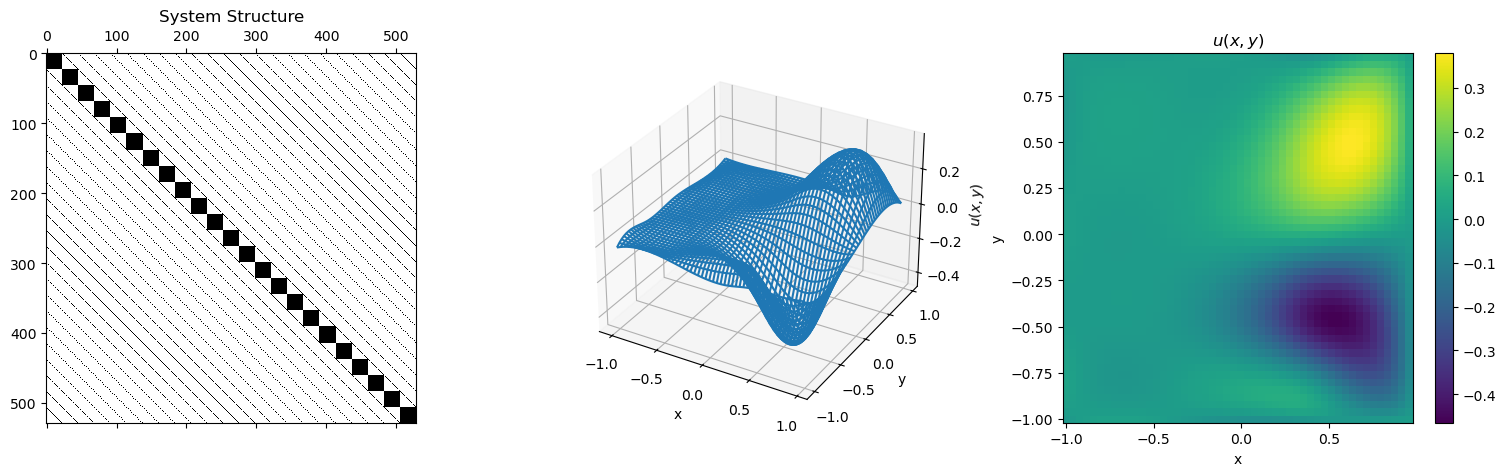

In [16]:
# Based on Trefethen program 16
import mpl_toolkits.mplot3d
import scipy.interpolate

f = lambda x, y: 10.0 * numpy.sin(8.0 * x * (y - 1.0))

N = 24
D, x = cheb(N)
X, Y = numpy.meshgrid(x[1:-1], x[1:-1])
X = X.flatten()
Y = Y.flatten()

D2 = numpy.dot(D, D)
D2 = D2[1:-1, 1:-1]
I = numpy.eye(N - 1)
L = numpy.kron(I, D2) + numpy.kron(D2, I)

# Solve system
U = numpy.linalg.solve(L, f(X, Y))

# Plot system structure and results
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 3)

axes = fig.add_subplot(1, 3, 1)
axes.spy(L)
axes.set_title("System Structure")

u = numpy.zeros((N + 1, N + 1))
u[1:-1, 1:-1] = U.reshape(N - 1, N - 1)
X, Y = numpy.meshgrid(x, x)
x_fine = numpy.arange(-1, 1, 0.04)
X_fine, Y_fine = numpy.meshgrid(x_fine, x_fine)
u_interpolant = scipy.interpolate.bisplrep(X, Y, u, s=1)
u_fine = scipy.interpolate.bisplev(x_fine, x_fine, u_interpolant)

axes = fig.add_subplot(1, 3, 2, projection='3d')
axes.plot_wireframe(X_fine, Y_fine, u_fine)
axes.set_xlabel('x')
axes.set_ylabel('y')
axes.set_zlabel('$u(x,y)$')

axes = fig.add_subplot(1, 3, 3)
plot = axes.pcolor(X_fine, Y_fine, u_fine)
axes.set_xlabel('x')
axes.set_ylabel('y')
axes.set_title('$u(x,y)$')
fig.colorbar(plot)

plt.show()

## FFT dan Chebyshev

FFT adalah alat yang sangat kuat yang membuat metode spektral menjadi sangat menarik, namun sejauh ini kita hanya melihat bagaimana FFT digunakan pada deret Fourier. Ternyata, serangkaian kesetaraan akan memungkinkan kita untuk menggunakan FFT pada deret Chebyshev juga.

Misalkan $z \in \mathbb C$ sedemikian hingga $|z| = 1$, misalkan $\theta$ adalah argumen dari $z$, yaitu $z = e^{i \theta}$ (perhatikan bahwa $\theta$ hanya unik hingga kelipatan $2\pi$), dan $x$ adalah bagian riil dari $z$ sehingga $x = \text{Re } z = \cos \theta$. Untuk semua $x \in [-1, 1]$, terdapat dua nilai $z$ yang bersesuaian dengan pergerakan naik dan turun menuju $z$ yang relevan pada lingkaran satuan, yaitu:


$$x = \text{Re } z = \frac{1}{2} (z + z^{-1}) = \cos \theta.$$

Sekarang tinjaulah polinomial Chebyshev $T_n(x)$ di mana polinomial ke-$(n+1)$ adalah:


$$T_{n+1}(x) = \frac{1}{2} (z^{n+1} + z^{-n-1})$$


yang juga bersesuaian dengan relasi rekurensi polinomial Chebyshev:


$$T_{n+1}(x) = 2 x T_n(x) - T_{n-1}(x).$$

Karena kita mengetahui bahwa $T_n(x)$ adalah polinomial derajat $n$, kita dapat menggunakan polinomial Chebyshev sebagai basis:


$$p(x) = \sum^\infty_{n=0} a_n T_n(x), \quad x \in [-1, 1].$$


Ini juga bersesuaian dengan polinomial Laurent derajat $N$ dalam $z$ dan $z^{-1}$ sedemikian hingga $z^n$ dan $z^{-n}$ memiliki koefisien yang sama:


$$\tilde{p}(z) = \frac{1}{2} \sum^\infty_{n=0} a_n (z^n + z^{-n}), \quad |z| = 1,$$


yang juga dikenal sebagai *self-reciprocal*. Terdapat pula polinomial lain dalam $\theta$ yang periodik $2\pi$ sedemikian hingga:


$$P(\theta) = \sum^\infty_{n=0} a_n \cos n \theta, \quad \theta \in \mathbb R.$$

Kesimpulannya, polinomial-polinomial ini ekuivalen jika kita memiliki hubungan yang telah didefinisikan antara variabel bebas $x, z,$ dan $\theta$. Mari kita tinjau bagaimana polinomial ini bertindak sebagai interpolan.

Misalkan $f(x)$ adalah fungsi sembarang pada $[-1, 1]$, kita dapat membentuk fungsi *self-reciprocal* $\tilde{f}(z)$ dengan:


$$\tilde{f}(z) = f\left(1/2 (z + z^{-1})\right)$$


dan secara korespondensi:


$$F(\theta) = f(\cos \theta).$$

Interpolan akan memiliki titik-titik simpul (nodes) pada:


$$\theta_j = j \pi / N, \quad z_j = e^{i\theta_j}, \quad \text{dan} \quad x_j = \cos \theta_j = \text{Re } z_j.$$

Proses dasar penggunaan FFT dengan deret Chebyshev adalah:

1. Diberikan $f$ sembarang, cari interpolan polinomial trigonometri $Q$ dari $F$,
2. Diferensialkan interpolan ini dalam ruang Fourier, dan
3. Transformasikan kembali ke domain asli pada $x \in [-1, 1]$.

Untuk membuktikan $T_{n+1}(x) = 2xT_n(x) - T_{n-1}(x)$ menggunakan $z$:
Diketahui $T_n(x) = \frac{1}{2}(z^n + z^{-n})$ dan $x = \frac{1}{2}(z + z^{-1})$.


$$2xT_n(x) = 2 \left[\frac{1}{2}(z + z^{-1})\right] \left[\frac{1}{2}(z^n + z^{-n})\right]$$

$$2xT_n(x) = \frac{1}{2}(z^{n+1} + z^{1-n} + z^{n-1} + z^{-(n+1)})$$

$$2xT_n(x) = \frac{1}{2}(z^{n+1} + z^{-(n+1)}) + \frac{1}{2}(z^{n-1} + z^{-(n-1)})$$

$$2xT_n(x) = T_{n+1}(x) + T_{n-1}(x)$$


Maka, $T_{n+1}(x) = 2xT_n(x) - T_{n-1}(x)$.


FFT bekerja pada data yang berjarak sama (*equispaced*). Titik-titik Chebyshev $x_j = \cos(j\pi/N)$ **tidak** berjarak sama pada sumbu $x$, tetapi jika kita melihatnya sebagai proyeksi dari lingkaran satuan, sudut $\theta_j = j\pi/N$ **berjarak sama** pada domain $\theta$.

Untuk menghitung turunan $f'(x)$ menggunakan FFT:

1. Perluas data $f(x_j)$ dari $N+1$ titik menjadi $2N$ titik secara simetris untuk membentuk fungsi periodik $F(\theta)$.
2. Gunakan FFT untuk mendapatkan koefisien Fourier.
3. Kalikan dengan $ik$ (operator turunan di ruang Fourier).
4. Gunakan Inverse FFT (IFFT) untuk kembali ke domain $\theta$.
5. Gunakan aturan rantai untuk kembali ke domain $x$:

$$\frac{df}{dx} = \frac{dF}{d\theta} \frac{d\theta}{dx} = \frac{dF/d\theta}{-\sin \theta}$$

In [17]:
# Based on Trefethen chebfft function
def chebfft(v):
    N = v.shape[0] - 1
    if N == 0:
        return 0
    x = numpy.cos(numpy.arange(N+1) * numpy.pi / N)
    ii = numpy.arange(N)
    
    # Transform x to \theta
    V = numpy.hstack((v, v[N-1:0:-1]))
    U = fft.fft(V).real
    wave_numbers = numpy.hstack((ii, [0], numpy.arange(1-N, 0)))
    W = fft.ifft(1j * wave_numbers * U).real
    w = numpy.zeros((N+1))
    
    # Transform back to x from \theta
    w[1:N] = -W[1:N] / numpy.sqrt(1.0 - x[1:N]**2)
    w[0] = numpy.sum(ii**2 * U[ii]) / N + 0.5 * N * U[N]
    w[-1] = numpy.sum((-1)**(ii + 1) * ii**2 * U[ii]) / N + 0.5 * (-1)**(N+1) * N * U[N]
    
    return w

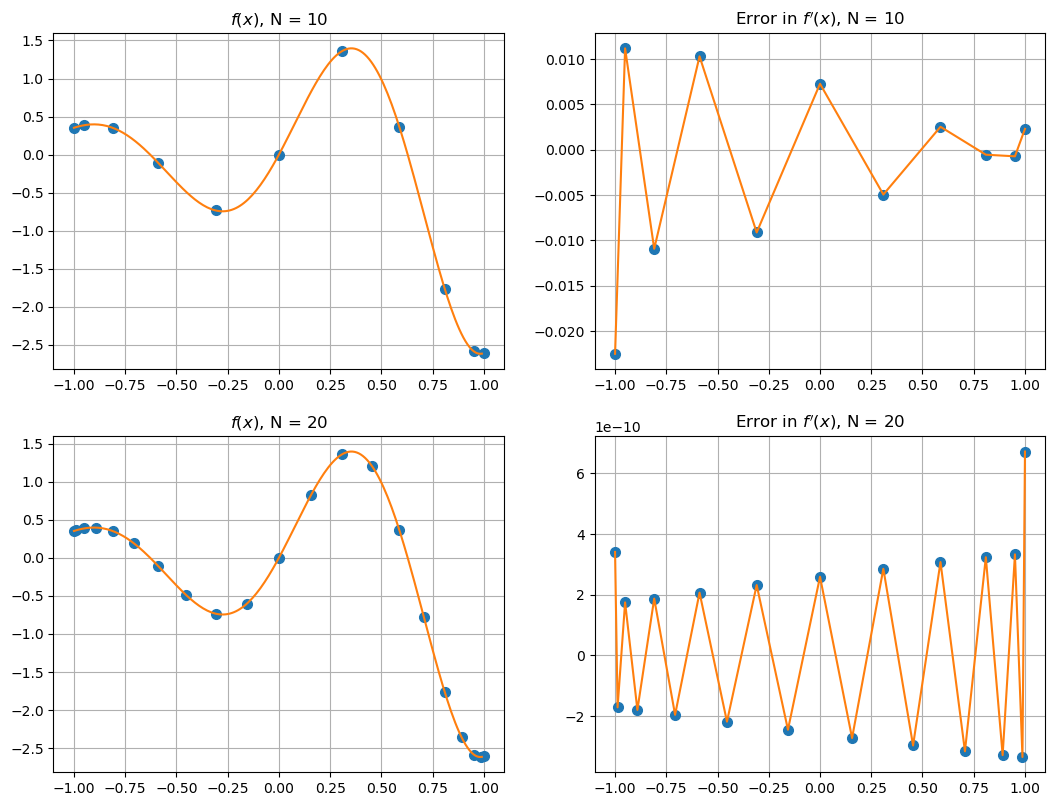

In [18]:
# Adaptation of program 18 in Trefethen
f = lambda x: numpy.exp(x) * numpy.sin(5.0 * x)
f_prime = lambda x: numpy.exp(x) * (numpy.sin(5.0 * x) + 5.0 * numpy.cos(5.0 * x))
x_fine = numpy.arange(-1, 1, 0.01)

fig, axes = plt.subplots(2, 2)
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)
for (i, N) in enumerate((10, 20)):
    x = numpy.cos(numpy.pi * numpy.arange(N+1) / N)
    axes[i, 0].plot(x, f(x), '.', markersize=14)
    axes[i, 0].plot(x_fine, f(x_fine))
    axes[i, 0].grid(True)
    axes[i, 0].set_title("$f(x)$, N = %s" % N)
    
    error = chebfft(f(x)) - f_prime(x)
    axes[i, 1].plot(x, error, '.', markersize=14)
    axes[i, 1].plot(x, error)
    axes[i, 1].grid(True)
    axes[i, 1].set_title("Error in $f'(x)$, N = %s" % N)

Kita juga dapat menerapkan metode ini untuk menyelesaikan PDE menggunakan metode spektral Chebyshev pada arah spasial dan beberapa diskritisasi waktu pada arah waktu. Tinjau persamaan gelombang orde kedua:$$u_{tt} = u_{xx}$$pada $\Omega = [-1, 1]$ dengan kondisi batas diatur ke $0$. Kita akan kembali menggunakan metode leapfrog untuk melakukan integrasi waktu.

(81,) 161 81


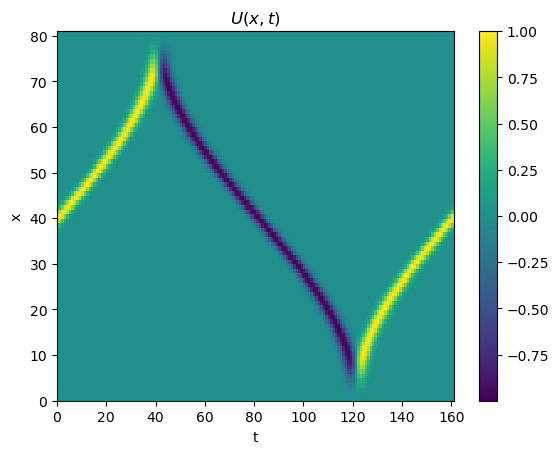

In [19]:
# Based on program 19 of Trefethen
# Solve the 2nd order wave equation on Chebyshev grid via leapfrog

N = 80
x = numpy.cos(numpy.pi * numpy.arange(0, N+1) / N)
delta_t = 8.0 / N**2
U = numpy.exp(-200.0 * x**2)
U_old = numpy.exp(-200.0 * (x - delta_t)**2)
t_final = 4.0

num_steps = int(numpy.ceil(t_final / delta_t))
plot_interval = 20
# t = numpy.linspace(0.0, t_final, num_steps)
t = 0.0
num_output = int(num_steps / plot_interval) + 1
t_output = numpy.empty(num_output)
t_output[0] = 0.0
U_output = numpy.empty((x.shape[0], num_output))
U_output[:, 0] = U.copy()
frame = 1
for n in range(num_steps):
    U_hat_dbl_prime = chebfft(chebfft(U))
    U_hat_dbl_prime[0] = 0.0
    U_hat_dbl_prime[-1] = 0.0
    
    U_new = 2.0 * U - U_old + delta_t**2 * U_hat_dbl_prime
    U_old = U.copy()
    U = U_new

    t += delta_t
    if numpy.mod(n, plot_interval) == 0:
        t_output[frame] = t
        U_output[:, frame] = U.copy()
        frame += 1

fig = plt.figure()
# fig.set_figwidth(fig.get_figwidth() * 2)
# fig.set_figheight(fig.get_figheight() * 2)
axes = fig.add_subplot(1, 1, 1)
print(x.shape, len(t_output), len(U_output))
# plot = axes.pcolor(x, t_output, U_output)
plot = axes.pcolor(U_output)
axes.set_xlabel("t")
axes.set_ylabel("x")
axes.set_title("$U(x,t)$")
fig.colorbar(plot)

plt.show()

## Kuadratur Spektral

Salah satu konsekuensi paling kuat dari banyak hal yang telah kita lakukan sebenarnya terlihat melalui integral. Karena integral adalah operasi penghalusan (*smoothing*), tidak mengherankan jika hal ini terjadi.

Jika kita ingin mengaproksimasi integral


$$I = \int^1_{-1} f(x) dx$$


salah satu caranya adalah dengan mencari polinomial interpolan dari $f(x)$ dan mengintegrasikan interpolan tersebut. Ini dikenal sebagai **kuadratur Clenshaw-Curtis** dan memiliki orde optimal pada set titik Chebyshev yang tetap.

Kita akan mengikuti proses yang digunakan untuk menghubungkan FFT ke deret Chebyshev sehingga kita mendapatkan:
$$\begin{aligned}
\int^1_{-1} p(x) dx &= \sum^N_{n=0, n \text{ genap}} \frac{2a_n}{1 - n^2}.
\end{aligned}$$
Dengan ini, kita menggunakan FFT untuk menentukan koefisien $a_n$ sebagaimana dijelaskan sebelumnya.

Gunakan substitusi $x = \cos \theta = \frac{1}{2}(z + z^{-1})$. Maka:


$$dx = \frac{1}{2}(1 - z^{-2}) dz$$


Integral dari basis Chebyshev $T_n(x) = \frac{1}{2}(z^n + z^{-n})$ terhadap $x$ menjadi:


$$\int T_n(x) dx = \int \frac{1}{2}(z^n + z^{-n}) \cdot \frac{1}{2}(1 - z^{-2}) dz$$

$$= \frac{1}{4} \int (z^n - z^{n-2} + z^{-n} - z^{-n-2}) dz$$


Antiturunan dari ekspresi di atas adalah:


$$\frac{1}{4} \left( \frac{z^{n+1}}{n+1} - \frac{z^{n-1}}{n-1} - \frac{z^{-n+1}}{-n+1} - \frac{z^{-n-1}}{-n-1} \right)$$


Kelompokkan suku-suku dengan penyebut yang sama:


$$\frac{1}{4} \left( \frac{z^{n+1} + z^{-(n+1)}}{n+1} - \frac{z^{n-1} + z^{-(n-1)}}{n-1} \right)$$


Batas $x = 1$ bersesuaian dengan $z = 1$, dan $x = -1$ bersesuaian dengan $z = -1$.

* Jika **$n$ ganjil**, maka $(n+1)$ dan $(n-1)$ adalah genap. Karena $(\pm 1)^{\text{genap}} = 1$, hasil pengurangan batas atas dan bawah adalah $1 - 1 = 0$.
* Jika **$n$ genap**, maka $(n+1)$ dan $(n-1)$ adalah ganjil. Maka $(1)^{\text{ganjil}} - (-1)^{\text{ganjil}} = 1 - (-1) = 2$.


Untuk $n$ genap, substitusi nilai 2 ke dalam hasil langkah ke-2:


$$\int^1_{-1} T_n(x) dx = \frac{1}{4} \left( \frac{2}{n+1} - \frac{2}{n-1} \right) \cdot 2 \text{ (dari simetri } z \text{ dan } z^{-1})$$


*(Catatan: karena kita bekerja dengan polinomial self-reciprocal, integrasi pada lingkaran satuan memberikan faktor tambahan).*
Penyederhanaan aljabar:


$$\frac{1}{n+1} - \frac{1}{n-1} = \frac{(n-1) - (n+1)}{(n+1)(n-1)} = \frac{-2}{n^2 - 1} = \frac{2}{1 - n^2}$$

Maka, total integralnya adalah jumlah koefisien $a_n$ dikali bobotnya:


$$I = \sum_{n \text{ genap}}^N \frac{2a_n}{1 - n^2}$$

In [24]:
def cheb_diff(N):
    """Compute the inverse differentiation matrix and return the x locations."""
    D, x = cheb(N)
    D_pinv = numpy.linalg.pinv(D[:-1, :-1])
    x = x[:-1]
    
    return D_pinv, x

In [31]:
import numpy as np

def clencurt(N):
    theta = np.pi*np.arange(N+1)/N
    x = np.cos(theta)
    w = np.zeros(N+1)
    ii = np.arange(1, N)
    v = np.ones(N-1)

    if N % 2 == 0:
        w[0] = 1/(N**2 - 1)
        w[-1] = w[0]
        for k in range(1, N//2):
            v -= 2*np.cos(2*k*theta[ii])/(4*k**2 - 1)
        v -= np.cos(N*theta[ii])/(N**2 - 1)
    else:
        w[0] = 1/N**2
        w[-1] = w[0]
        for k in range(1, (N+1)//2):
            v -= 2*np.cos(2*k*theta[ii])/(4*k**2 - 1)

    w[ii] = 2*v/N
    return x, w

<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\e'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15472\2132205195.py:28: SyntaxWarning: invalid escape sequence '\e'
  titles = ['$|x^3|$', '$\exp(-x^{-2})$', '$1 / (1 + x^2)$', '$x^10$']


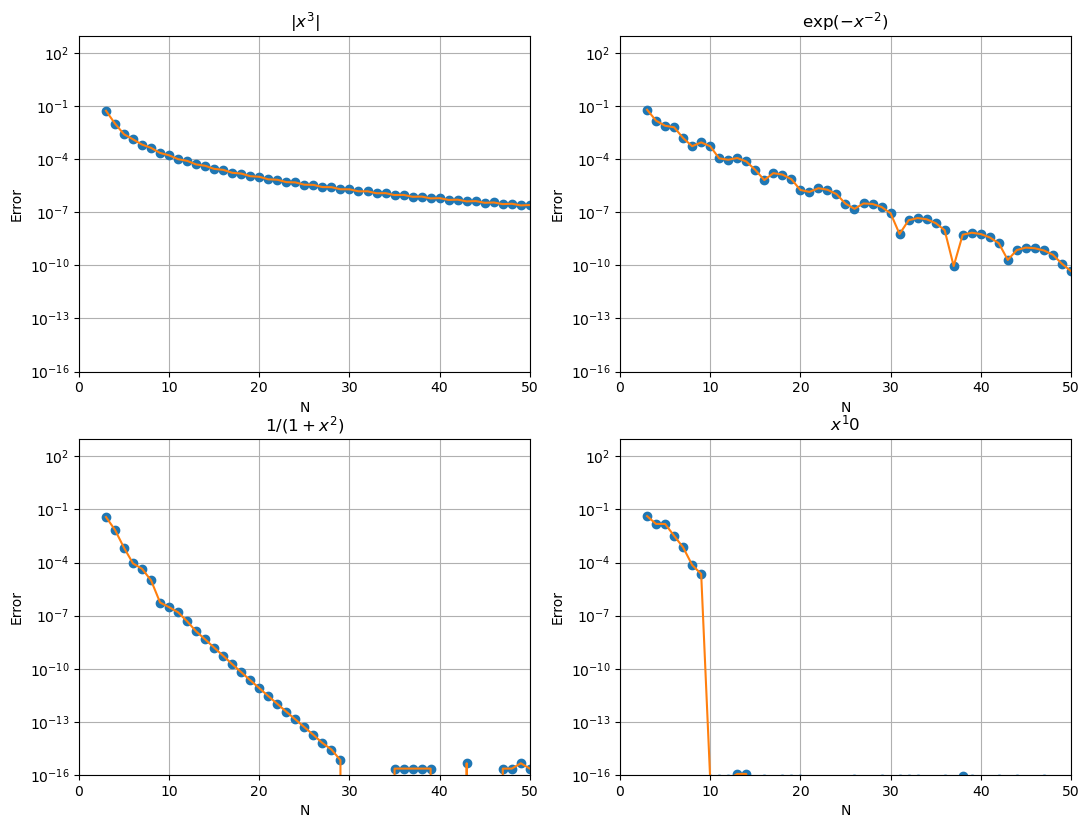

In [32]:
# Compare errors more carefully (program 30 in Trefethen)
#  Example directly uses Chebyshev differentiation matrix
import scipy.special

N_max = 50
error = numpy.zeros((4, N_max - 2))
N_range = numpy.arange(3, N_max + 1)
for (i, N) in enumerate(N_range):
    x, w = clencurt(N)

    f = np.abs(x)**3
    error[0,i] = abs(np.dot(w,f) - 0.5)

    f = np.exp(-1/x**2); f[x==0]=0
    f_int = 2*(np.exp(-1)+np.sqrt(np.pi)*(scipy.special.erf(1)-1))
    error[1,i] = abs(np.dot(w,f) - f_int)

    f = 1/(1+x**2)
    error[2,i] = abs(np.dot(w,f) - np.pi/2)

    f = x**10
    error[3,i] = abs(np.dot(w,f) - 2/11)
    
# Plot errors
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)
titles = ['$|x^3|$', '$\exp(-x^{-2})$', '$1 / (1 + x^2)$', '$x^10$']
for (i, title) in enumerate(titles):
    axes = fig.add_subplot(2, 2, i + 1)
    axes.semilogy(N_range, error[i, :], '.', markersize=12)
    axes.semilogy(N_range, error[i, :])
    axes.set_xlim((0, N_max))
    axes.set_ylim((1e-16, 1e3))
    axes.grid(True)
    axes.set_xlabel("N")
    axes.set_ylabel("Error")
    axes.set_title(title)

In [35]:
import numpy as np

def clencurt(N):
    theta = np.pi * np.arange(N+1) / N
    x = np.cos(theta)

    w = np.zeros(N+1)
    ii = np.arange(1, N)
    v = np.ones(N-1)

    if N % 2 == 0:
        w[0] = 1/(N**2-1)
        w[-1] = w[0]
        for k in range(1, N//2):
            v -= 2*np.cos(2*k*theta[ii])/(4*k**2-1)
        v -= np.cos(N*theta[ii])/(N**2-1)
    else:
        w[0] = 1/N**2
        w[-1] = w[0]
        for k in range(1, (N+1)//2):
            v -= 2*np.cos(2*k*theta[ii])/(4*k**2-1)

    w[ii] = 2*v/N

    return w, x

<>:32: SyntaxWarning: invalid escape sequence '\e'
<>:32: SyntaxWarning: invalid escape sequence '\e'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15472\1757459883.py:32: SyntaxWarning: invalid escape sequence '\e'
  titles = ['$|x^3|$', '$\exp(-x^{-2})$', '$1 / (1 + x^2)$', '$x^10$']


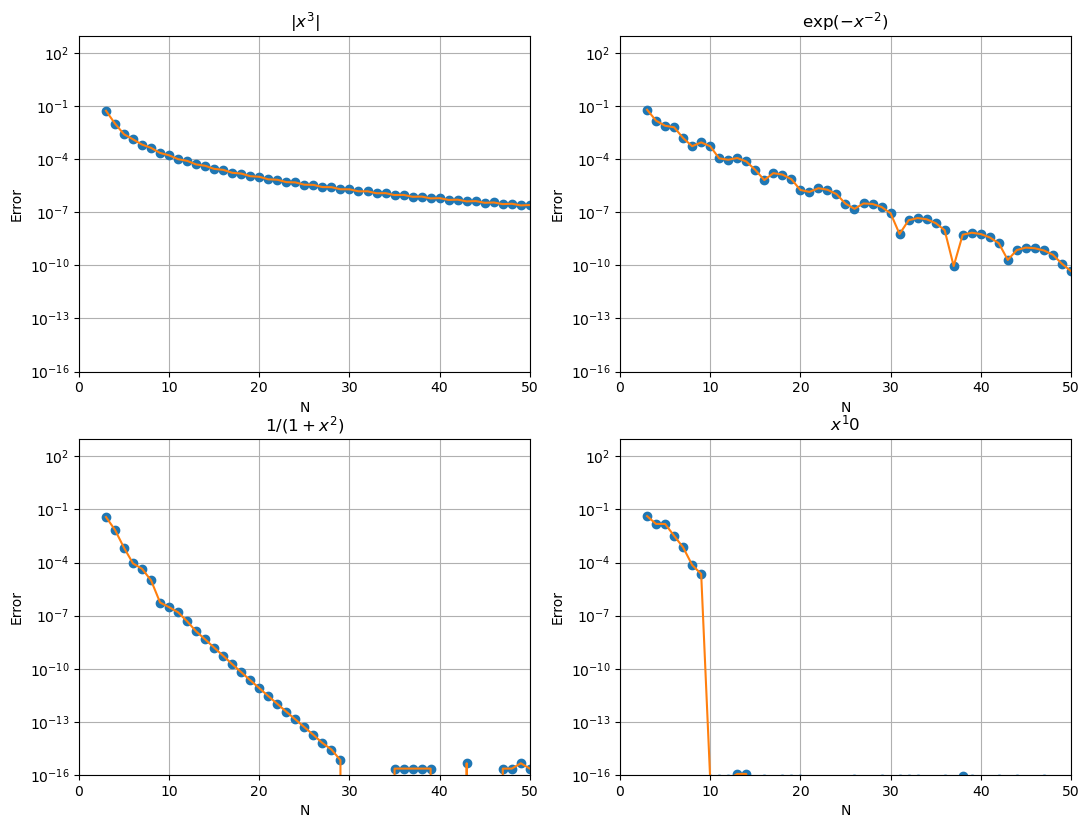

In [36]:
# Compare errors more carefully (program 30 in Trefethen)
#  Example using Clenshaw-Curtis quadrature weights
import scipy.special

N_max = 50
error = numpy.zeros((4, N_max - 2))
N_range = numpy.arange(3, N_max + 1)
for (i, N) in enumerate(N_range):
    w, x = clencurt(N)
    
    # 3rd derivative of bounded variation
    f = numpy.abs(x)**3
    f_int = 0.5
    error[0, i] = numpy.abs(numpy.dot(w, f) - f_int)
    # C_\infty function
    f = numpy.exp(-x**(-2))
    f_int = 2.0 * (numpy.exp(-1) + numpy.sqrt(numpy.pi) * (scipy.special.erf(1) - 1))
    error[1, i] = numpy.abs(numpy.dot(w, f) - f_int)
    # Analytic on [-1, 1]
    f = 1.0 / (1.0 + x**2)
    f_int = numpy.pi / 2.0
    error[2, i] = numpy.abs(numpy.dot(w, f) - f_int)
    # Polynomial
    f = x**10
    f_int = 2.0 / 11.0
    error[3, i] = numpy.abs(numpy.dot(w, f) - f_int)
    
# Plot errors
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)
titles = ['$|x^3|$', '$\exp(-x^{-2})$', '$1 / (1 + x^2)$', '$x^10$']
for (i, title) in enumerate(titles):
    axes = fig.add_subplot(2, 2, i + 1)
    axes.semilogy(N_range, error[i, :], '.', markersize=12)
    axes.semilogy(N_range, error[i, :])
    axes.set_xlim((0, N_max))
    axes.set_ylim((1e-16, 1e3))
    axes.grid(True)
    axes.set_xlabel("N")
    axes.set_ylabel("Error")
    axes.set_title(title)

In [37]:
def gauss(N):
    beta = 0.5 / numpy.sqrt(1.0 - (2.0 * numpy.arange(1, N))**(-2))
    T = numpy.diag(beta, 1) + numpy.diag(beta, -1)
    x, V = numpy.linalg.eig(T)
    i = numpy.argsort(x)
    x = x[i]
    w = 2.0 * V[0, i]**2
    return w, x

<>:32: SyntaxWarning: invalid escape sequence '\e'
<>:32: SyntaxWarning: invalid escape sequence '\e'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15472\3072884163.py:32: SyntaxWarning: invalid escape sequence '\e'
  titles = ['$|x^3|$', '$\exp(-x^{-2})$', '$1 / (1 + x^2)$', '$x^10$']


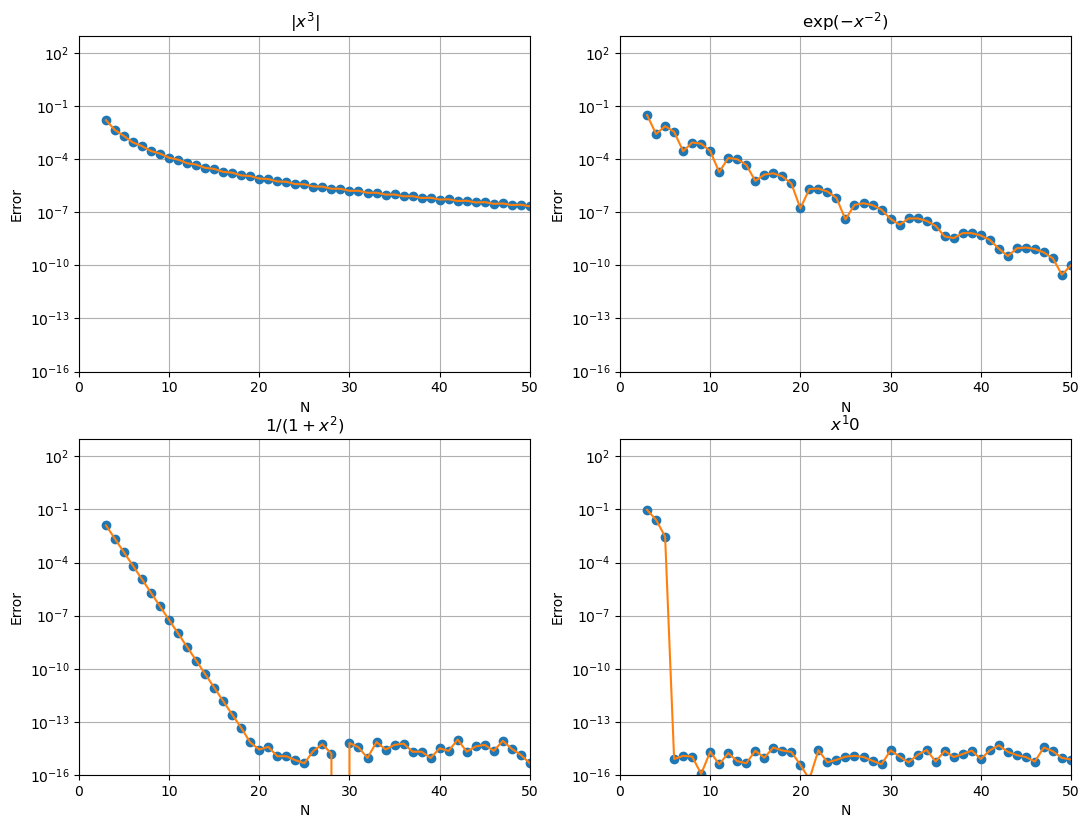

In [38]:
# Compare errors more carefully (program 30 in Trefethen)
#  Example using Gaussian quadrature (using Legendre points)
import scipy.special

N_max = 50
error = numpy.zeros((4, N_max - 2))
N_range = numpy.arange(3, N_max + 1)
for (i, N) in enumerate(N_range):
    w, x = gauss(N)
    
    # 3rd derivative of bounded variation
    f = numpy.abs(x)**3
    f_int = 0.5
    error[0, i] = numpy.abs(numpy.dot(w, f) - f_int)
    # C_\infty function
    f = numpy.exp(-x**(-2))
    f_int = 2.0 * (numpy.exp(-1) + numpy.sqrt(numpy.pi) * (scipy.special.erf(1) - 1))
    error[1, i] = numpy.abs(numpy.dot(w, f) - f_int)
    # Analytic on [-1, 1]
    f = 1.0 / (1.0 + x**2)
    f_int = numpy.pi / 2.0
    error[2, i] = numpy.abs(numpy.dot(w, f) - f_int)
    # Polynomial
    f = x**10
    f_int = 2.0 / 11.0
    error[3, i] = numpy.abs(numpy.dot(w, f) - f_int)
    
# Plot errors
fig = plt.figure()
fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)
titles = ['$|x^3|$', '$\exp(-x^{-2})$', '$1 / (1 + x^2)$', '$x^10$']
for (i, title) in enumerate(titles):
    axes = fig.add_subplot(2, 2, i + 1)
    axes.semilogy(N_range, error[i, :], '.', markersize=12)
    axes.semilogy(N_range, error[i, :])
    axes.set_xlim((0, N_max))
    axes.set_ylim((1e-16, 1e3))
    axes.grid(True)
    axes.set_xlabel("N")
    axes.set_ylabel("Error")
    axes.set_title(title)